#Project Initialization & Environment Setup

###The initialization process includes:

* **Clone the Project Repository:** We use `git clone` to fetch the primary codebase from the official `llm-as-a-judge-praktikum` repository into our current workspace.

* **Clone the Shared-Task Dataset:** We download the benchmark dataset repository (`wmt-mist`) which contains the evaluations and test data needed for this specific task.

* **Install Dependencies:** Finally, we run `pip install -r requirements.txt` to automatically install all necessary Python packages and libraries, ensuring a fully compatible and error-free execution environment.


In [1]:
# Clone the project repository
!git clone https://github.com/NhAnh278/llm-as-a-judge-praktikum.git

Cloning into 'llm-as-a-judge-praktikum'...


remote: Enumerating objects: 150, done.


remote: Counting objects: 100% (150/150), done.


remote: Compressing objects: 100% (140/140), done.


remote: Total 150 (delta 88), reused 23 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (150/150), 8.37 MiB | 3.23 MiB/s, done.


Resolving deltas: 100% (88/88), done.


In [2]:
# Clone the WMT shared-task dataset repository
!git clone https://github.com/wmt-conference/wmt-mist.git

Cloning into 'wmt-mist'...


remote: Enumerating objects: 165, done.


remote: Total 165 (delta 0), reused 0 (delta 0), pack-reused 165 (from 1)


Receiving objects: 100% (165/165), 199.31 MiB | 5.99 MiB/s, done.


Resolving deltas: 100% (69/69), done.


Updating files: 100% (83/83), done.


In [3]:
# Enter the project repository
%cd llm-as-a-judge-praktikum

/tmp/claude-1000/-home-nhanh-llm-as-a-judge-praktikum/14f6ffa4-a8cd-40a5-8caf-b6d16e658377/scratchpad/exec_env/llm-as-a-judge-praktikum


/home/nhanh/.local/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [5]:
# Install project dependencies
!pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable


# Week 1 Summary: (human-rating) Dataset Loading & Exploratory Data Analysis (EDA)

During the first week, the primary focus was on loading the human-rating evaluation dataset and conducting a thorough Exploratory Data Analysis (EDA) to understand its structural properties, distribution, and core metrics.

In [1]:
# Switch into the wmt-mist dataset repository
%cd ..
%cd wmt-mist

/tmp/content3
/tmp/content3/wmt-mist


/home/nhanh/.local/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
# Load the human ratings JSON file
import json
import pandas as pd
import urllib.request
from pathlib import Path

# mist_25.json is tracked with Git LFS in the wmt-mist repo. A plain `git clone`
# (no git-lfs installed, e.g. on Colab) only downloads a small LFS pointer stub
# ("version https://git-lfs...") instead of the real ~26MB file, which makes the
# later segment_id merge silently lose rows or crash outright. We prefer the
# copy committed in this project's own data/ folder (added precisely to avoid
# this), and fall back to the official WMT25 mirror if that's missing too.
MIST_MIRROR_URL = "https://data.statmt.org/wmt25/general-mt/blindset_mist_2025.json"
PROJECT_MIST_PATH = Path("../llm-as-a-judge-praktikum/data/mist_25.json")

# data/humeval/oeg.json and data/submissions_judge_oeg/*.json are NOT tracked
# with Git LFS, but a `wmt-mist` clone can still fail or come back incomplete
# (flaky network, partial clone) -- this is exactly what silently produced
# wrong pairwise-accuracy / acc_eq numbers before. We now keep a verified copy
# of both (checked against the WMT25 organizers' own ground-truth numbers in
# data/humeval_aggregated/judge_oeg.json) in this project's own data/ folder,
# and prefer that over the fresh wmt-mist clone.
PROJECT_HUMAN_PATH = Path("../llm-as-a-judge-praktikum/data/humeval/oeg.json")
PROJECT_JUDGE_DIR = Path("../llm-as-a-judge-praktikum/data/submissions_judge_oeg")


def is_lfs_pointer(path):
    if not path.exists():
        return True
    with open(path, "r", encoding="utf-8", errors="ignore") as fh:
        return fh.read(200).startswith("version https://git-lfs")


def resolve_mist_path():
    for candidate in [PROJECT_MIST_PATH, Path("data/mist_25.json")]:
        if candidate.exists() and not is_lfs_pointer(candidate):
            return candidate
    target = PROJECT_MIST_PATH
    target.parent.mkdir(parents=True, exist_ok=True)
    print(f"mist_25.json not usable locally, downloading from {MIST_MIRROR_URL} ...")
    urllib.request.urlretrieve(MIST_MIRROR_URL, target)
    return target


def resolve_human_path():
    if PROJECT_HUMAN_PATH.exists() and not is_lfs_pointer(PROJECT_HUMAN_PATH):
        return PROJECT_HUMAN_PATH
    return Path("data/humeval/oeg.json")


def resolve_judge_dir():
    if PROJECT_JUDGE_DIR.exists() and any(PROJECT_JUDGE_DIR.glob("*.json")):
        return PROJECT_JUDGE_DIR
    return Path("data/submissions_judge_oeg")


mist_path = resolve_mist_path()
print(f"Using mist_25.json from: {mist_path}")

human_path = resolve_human_path()
print(f"Using human ratings from: {human_path}")

judge_dir = resolve_judge_dir()
print(f"Using judge submissions from: {judge_dir}")

with open(human_path, "r", encoding="utf-8") as f:
  human_data = json.load(f)
type(human_data), len(human_data)

Using mist_25.json from: ../llm-as-a-judge-praktikum/data/mist_25.json
Using human ratings from: ../llm-as-a-judge-praktikum/data/humeval/oeg.json
Using judge submissions from: ../llm-as-a-judge-praktikum/data/submissions_judge_oeg


(list, 7360)

In [3]:
# Convert the loaded data into a DataFrame
df_human = pd.DataFrame(human_data)
df_human.head()

,system,prompt,response,doc_id,language_locale,coherence,naturalness,instruction_following,mean_score,rater,language
0,Gemma-3-12B,إنت ممثل خدمة عملا في شركة تكنولوجيا. عميل كلم...,أهلاً بك [اسم العميل]،<br><br>شكرًا لك على الا...,104373856e995a074579797ebe34fcb2,Egyptian Arabic,7.0,1.0,7.0,5.000000,rater1_ar_EG,ar_EG
1,Gemma-3-12B,من فضلكم، أنا بتلقى رسائل إلكترونية دعائية بشك...,تمام، هذا طلب رسمي ومهم جدًا. إليك صيغة مُحسّن...,fb2c387e7e5272a43305940219116463,Egyptian Arabic,6.0,5.0,6.0,5.666667,rater2_ar_EG,ar_EG
2,Mistral-Medium,صاحبك القريب منك مسافر برة البلد ومتوتر إنه هي...,**عزيزي صديقي،**<br><br>أعلم أن هذه اللحظة ملي...,e91353a8c4dde03994b2cbfb5521172e,Egyptian Arabic,5.0,1.0,5.0,3.666667,rater2_ar_EG,ar_EG
3,Qwen3-235B,اكتب حوار بالمصري بين اتنين صحاب، واحد فيهم بي...,**[موقف: صحابين قاعدين في الكافيتيريا، واحد من...,170d490a7ae53347e8fe3eabe4e28001,Egyptian Arabic,7.0,4.0,7.0,6.000000,rater3_ar_EG,ar_EG
4,CommandR7B,أنا سكنت مؤخرًا في سكن طلاب. لاحظت إن واحد من ...,يمكنك كتابة ملحوظة لزقة على النحو التالي:<br><...,14e076d13751e87d8c09f7f13125e755,Egyptian Arabic,7.0,1.0,7.0,5.000000,rater3_ar_EG,ar_EG


In [4]:
# Check dataset shape
df_human.shape

(7360, 11)

In [5]:
# List dataset columns
df_human.columns

Index(['system', 'prompt', 'response', 'doc_id', 'language_locale',
       'coherence', 'naturalness', 'instruction_following', 'mean_score',
       'rater', 'language'],
      dtype='object')

###1. Dataset Dimensions & Schema
The dataset was successfully loaded into a pandas DataFrame. Initial inspection reveals a well-structured and clean schema:
* **Shape:** `(7360, 11)` — The dataset contains **7,360 rows** (evaluation samples) and **11 columns** (features).
* **Column Inventory:** `['system', 'prompt', 'response', 'doc_id', 'language_locale', 'coherence', 'naturalness', 'instruction_following', 'mean_score', 'rater', 'language']`



In [6]:
# Summary statistics for the human score columns
df_human[[
    "coherence",
    "naturalness",
    "instruction_following",
    "mean_score"
]].describe()
#score is between 1 and 7
#naturalness has a lowest mean
#instruction_following looks really good with the highest mean score
#generally, human ratings are really high

,coherence,naturalness,instruction_following,mean_score
count,7360.000000,7360.000000,7360.000000,7360.000000
mean,5.790217,5.347554,5.869973,5.669248
std,1.588282,1.789316,1.496409,1.419300
min,1.000000,1.000000,1.000000,1.000000
25%,5.000000,5.000000,5.000000,5.000000
50%,7.000000,6.000000,7.000000,6.000000
75%,7.000000,7.000000,7.000000,7.000000
max,7.000000,7.000000,7.000000,7.000000


###2. Statistical Summary of Human Ratings
The dataset contains human quality scores across three primary dimensions (`coherence`, `naturalness`, `instruction_following`), alongside a final consolidated `mean_score`. All metrics are rated on a **1 to 7 scale**.


**Key Insight:** The distribution of scores is skewed toward higher quality, with median scores sitting at `6.0` or `7.0`. Models generally perform best at *Instruction Following* (Mean: 5.87) and struggle slightly more with *Naturalness* (Mean: 5.35).

In [7]:
# Count samples per system
df_human["system"].value_counts()

system
Gemma-3-12B         460
Mistral-Medium      460
Qwen3-235B          460
CommandR7B          460
Llama-3             460
DeepSeek-V3         460
Mistral-7B          460
AyaExpanse-32B      460
Claude-4            460
Gemma-3-27B         460
Llama-4-Maverick    460
CommandA            460
Qwen2               460
AyaExpanse-8B       460
Gemini-2            460
GPT-4               460
Name: count, dtype: int64

In [8]:
# Count samples per language locale
df_human["language_locale"].value_counts()

language_locale
Egyptian Arabic               736
English (United States)       736
German (Germany)              736
Simplified Chinese (China)    736
Hindi (India)                 736
Czech (Czechia)               736
Indonesian (Indonesia)        736
Japanese (Japan)              736
Russian (Russia)              736
Bangla (Bangladesh)           736
Name: count, dtype: int64

###3. Linguistic & Geographic Distribution
There are exactly **736 samples per locale** across **10 distinct linguistic regions**:

* 🇪🇬 **Egyptian Arabic** (736)
* 🇺🇸 **English** (United States) (736)
* 🇩🇪 **German** (Germany) (736)
* 🇨🇳 **Simplified Chinese** (China) (736)
* 🇮🇳 **Hindi** (India) (736)
* 🇨🇿 **Czech** (Czechia) (736)
* 🇮🇩 **Indonesian** (Indonesia) (736)
* 🇯🇵 **Japanese** (Japan) (736)
* 🇷🇺 **Russian** (Russia) (736)
* 🇧🇩 **Bangla** (Bangladesh) (736)


the shared task dataset contains :

- 7360 rows
- 46 doc_id
- 10 languages
- 16 systems
- 460 unique prompts

so we have:
46 doc_id × 10 languages × 16 systems = 7360 rows

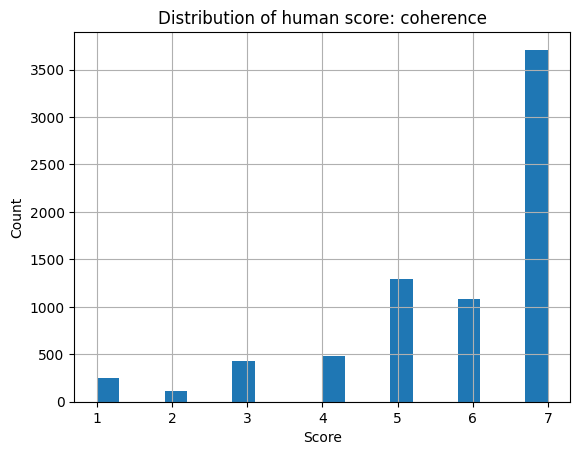

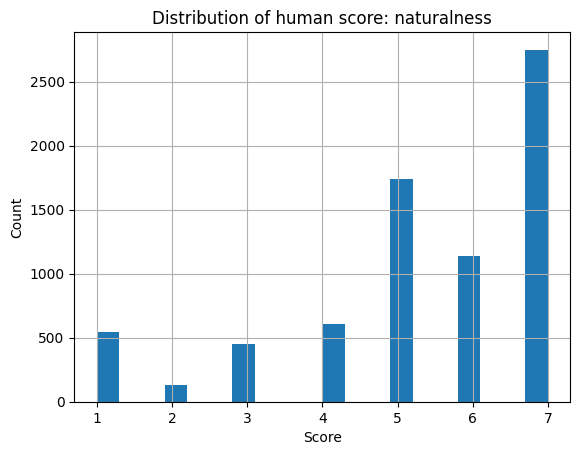

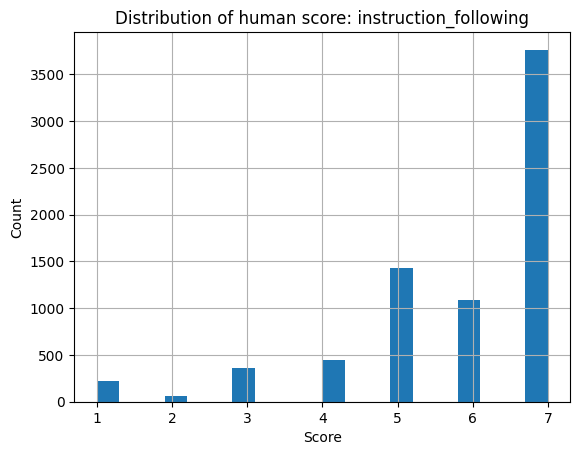

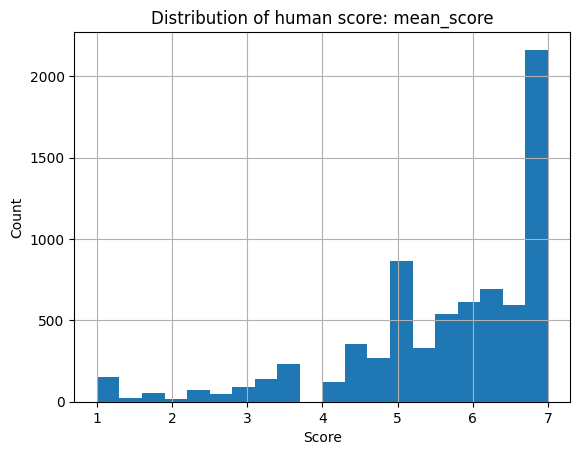

In [9]:
# Plot histograms of human scores per aspect
score_cols = [
    "coherence",
    "naturalness",
    "instruction_following",
    "mean_score"
]

import matplotlib.pyplot as plt

for col in score_cols:
  plt.figure()
  df_human[col].hist(bins=20)
  plt.title(f"Distribution of human score: {col}")
  plt.xlabel("Score")
  plt.ylabel("Count")
  plt.show()

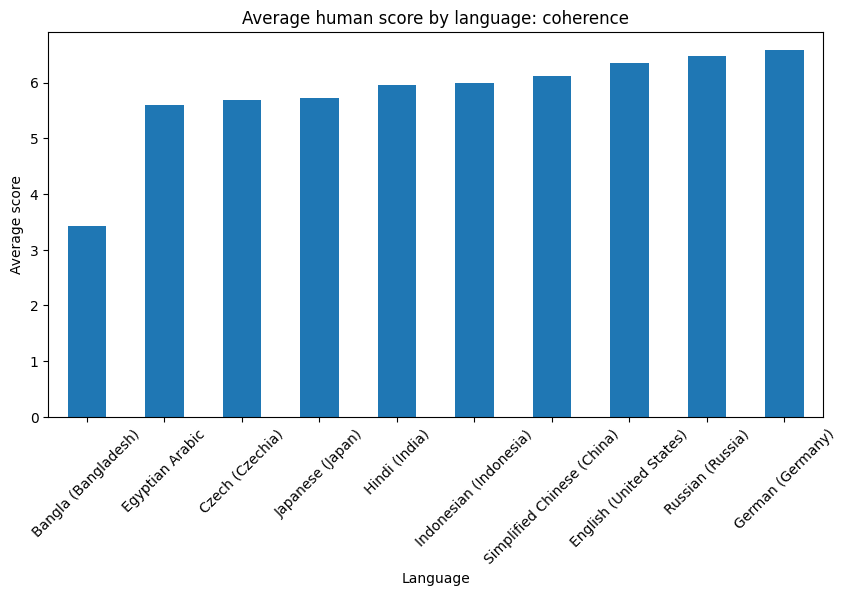

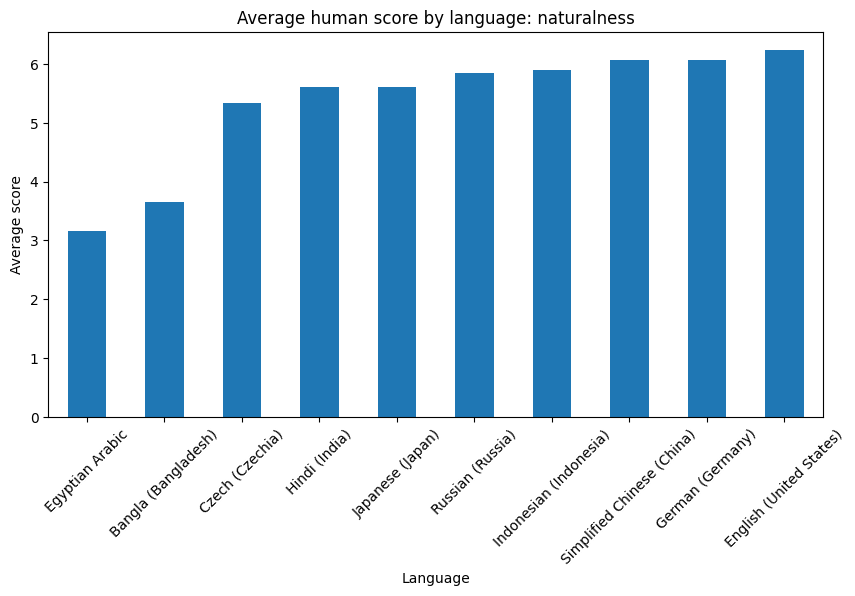

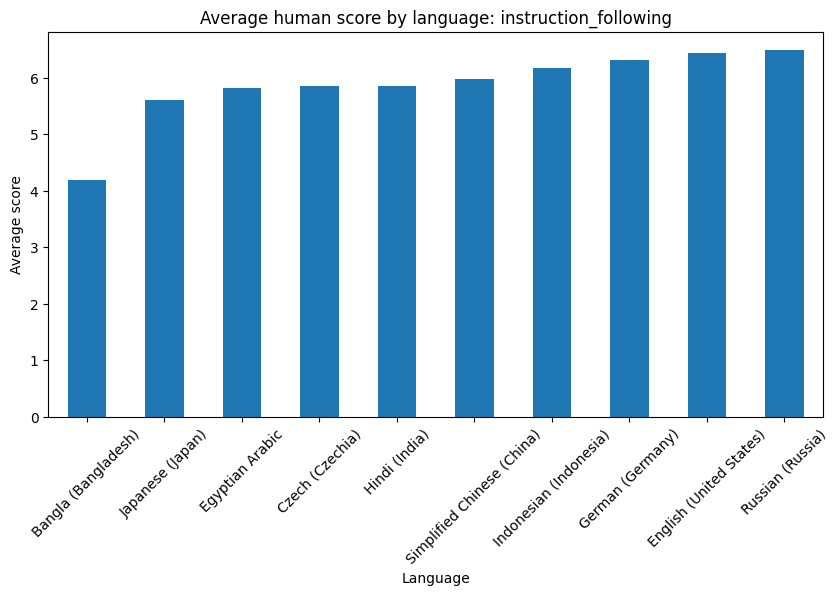

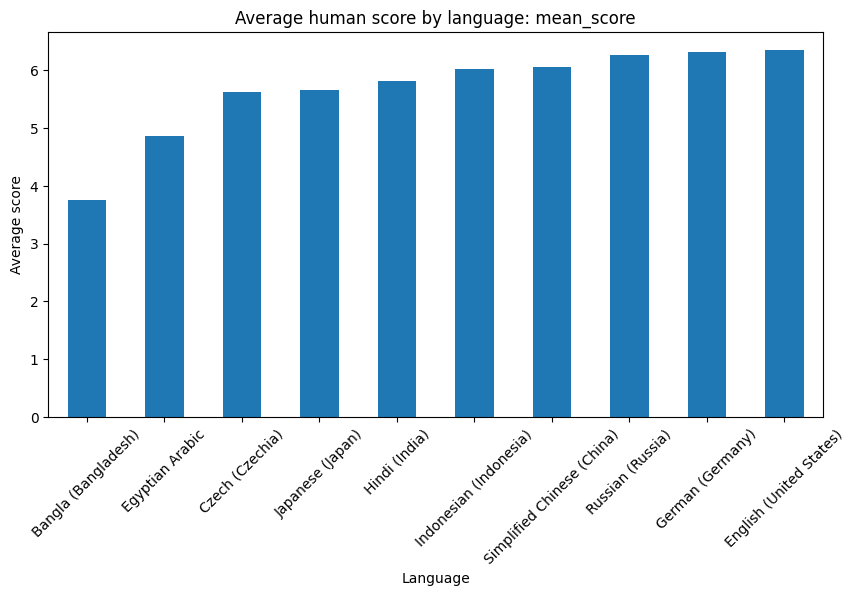

In [10]:
# Plot average human score per language
for col in score_cols:
    lang_scores = df_human.groupby("language_locale")[col].mean().sort_values()

    plt.figure(figsize=(10, 5))
    lang_scores.plot(kind="bar")
    plt.title(f"Average human score by language: {col}")
    plt.xlabel("Language")
    plt.ylabel("Average score")
    plt.xticks(rotation=45)
    plt.show()

###4. Deep-Dive Visual Data Analysis

To better understand the human evaluation behavior, we generated distribution plots for each quality metric and analyzed how performance varies across different languages.



####A. Score Distributions (Histograms)
Looking at the distribution of scores across the four criteria, we notice a clear **positivity bias** in human annotations:

* **Coherence & Instruction Following:** These two metrics exhibit the strongest left-skewed distribution. The vast majority of the 7,360 evaluations are concentrated at a score of `7` (over 3,500 samples each), meaning human raters found the generated responses highly logical and compliant with the initial prompts.
* **Naturalness:** While still heavily skewed toward higher scores, `naturalness` shows a more spread-out distribution compared to coherence. The bar for a score of `5` is significantly higher here, indicating that generating truly fluent, native-sounding text across all languages remains a slightly harder task for the evaluated systems.
* **Mean Score:** Combining all dimensions creates a smoother, multi-modal distribution that peaks sharply at `7`, with secondary clusters around the integer values `5` and `6`.


####B. Language-Specific Performance Breakdown (Bar Charts)
Analyzing the average human score grouped by language reveals interesting cross-lingual variations and identifies where language models struggle the most:

| Metric | Highest Performing Languages | Lowest Performing Languages |
| :--- | :--- | :--- |
| **Coherence** | German, Russian, English (`~6.5`) | Bangla (`~3.4`), Egyptian Arabic (`~5.6`) |
|**Naturalness** | English, German, Simplified Chinese (`>6.0`) | Egyptian Arabic (`~3.2`), Bangla (`~3.6`) |
|**Instruction Following** | Russian, English, German (`~6.5`) | Bangla (`~4.2`), Japanese, Egyptian Arabic (`~5.6`) |
|**Overall Mean Score** | English, German, Russian (`>6.0`) | Bangla (`~3.8`), Egyptian Arabic (`~4.9`) |

####Critical Observations & Data Insights:
1. **The Western-Language Dominance:** Across all four sub-plots, **English (US)**, **German**, and **Russian** consistently anchor the top 3 positions with the highest average scores. This indicates that the underlying generative models are highly mature in high-resource, Western languages.
2. **The Bangla Bottleneck:** **Bangla (Bangladesh)** is a prominent outlier across almost every chart, particularly in *Coherence* and *Overall Mean Score* where its average sits below `4.0`. This reveals a severe performance gap, suggesting either a low-resource limitation in the evaluated systems or stricter grading criteria from the Bangla human raters.
3. **The Localized Dialect Challenge:** While Standard Arabic datasets usually perform moderately well, **Egyptian Arabic** scores exceptionally low in *Naturalness* (`~3.2`). This demonstrates the classic difficulty language models face when dealing with colloquial dialectal variants versus Modern Standard Arabic (MSA).

In [11]:
# Compute average human score per model/system
score_cols = ["coherence", "naturalness", "instruction_following", "mean_score"]

model_scores = (
    df_human
    .groupby("system")[score_cols]
    .mean()
    .sort_values("mean_score", ascending=False)
)

model_scores

,coherence,naturalness,instruction_following,mean_score
system,,,,
GPT-4,6.200000,5.936957,6.239130,6.125362
Gemini-2,6.215217,5.797826,6.247826,6.086957
DeepSeek-V3,6.091304,5.645652,6.169565,5.968841
Claude-4,6.082609,5.741304,6.056522,5.960145
Mistral-Medium,6.032609,5.680435,6.158696,5.957246
Gemma-3-27B,6.065217,5.591304,6.152174,5.936232
CommandA,6.028261,5.645652,6.119565,5.931159
Qwen3-235B,5.993478,5.565217,6.134783,5.897826
Llama-4-Maverick,5.930435,5.734783,6.017391,5.894203


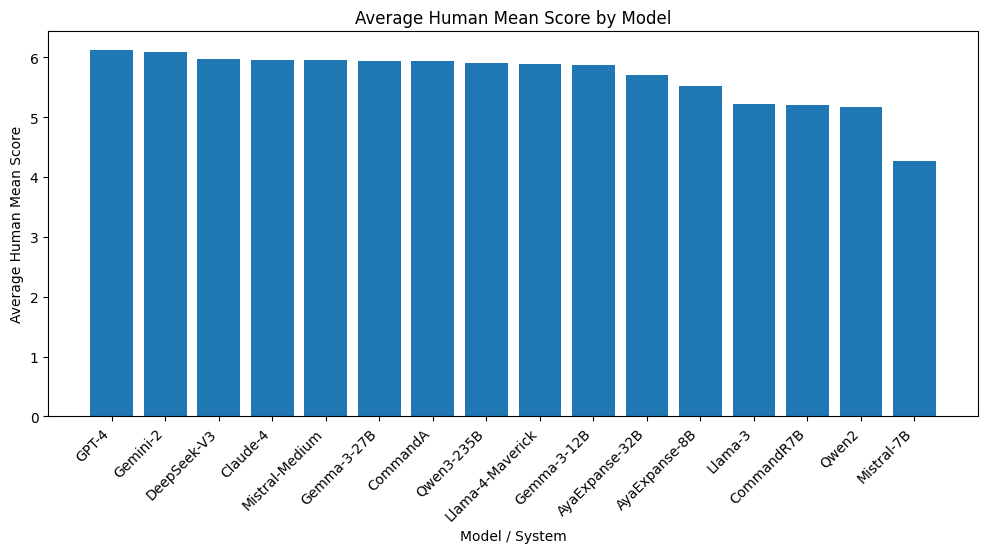

In [12]:
# Plot average mean_score per model
model_mean = (
    df_human
    .groupby("system")["mean_score"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 5))
plt.bar(model_mean.index, model_mean.values)
plt.title("Average Human Mean Score by Model")
plt.xlabel("Model / System")
plt.ylabel("Average Human Mean Score")
plt.xticks(rotation=45, ha="right")
plt.show()

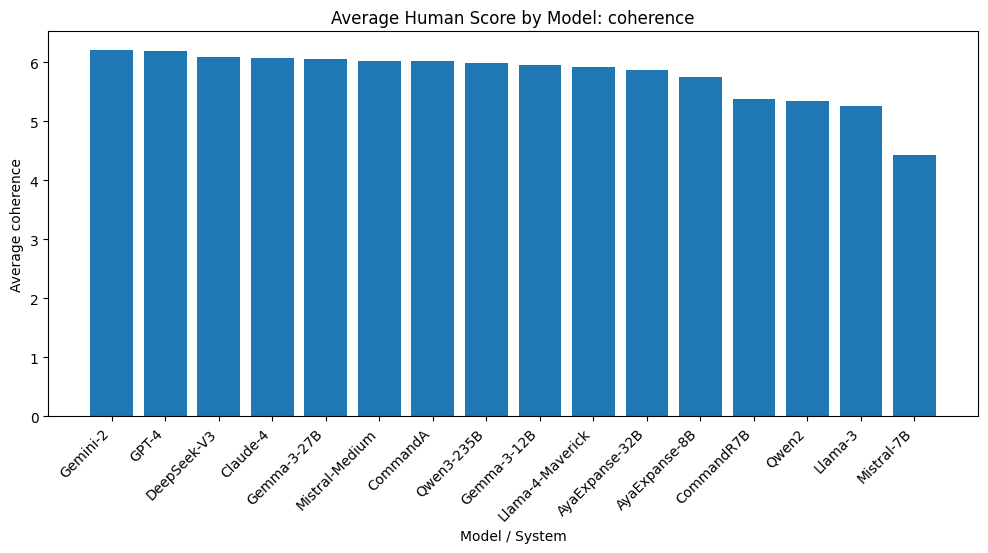

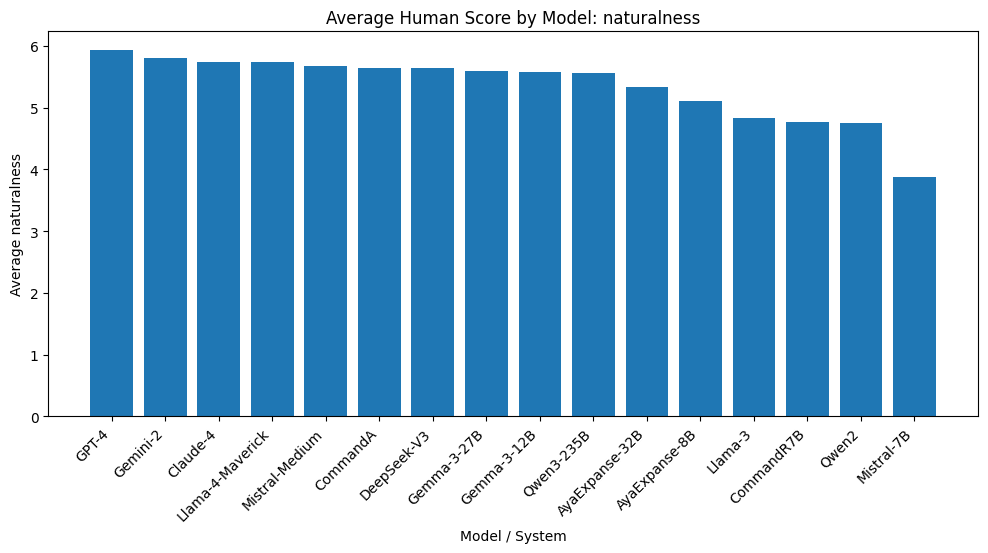

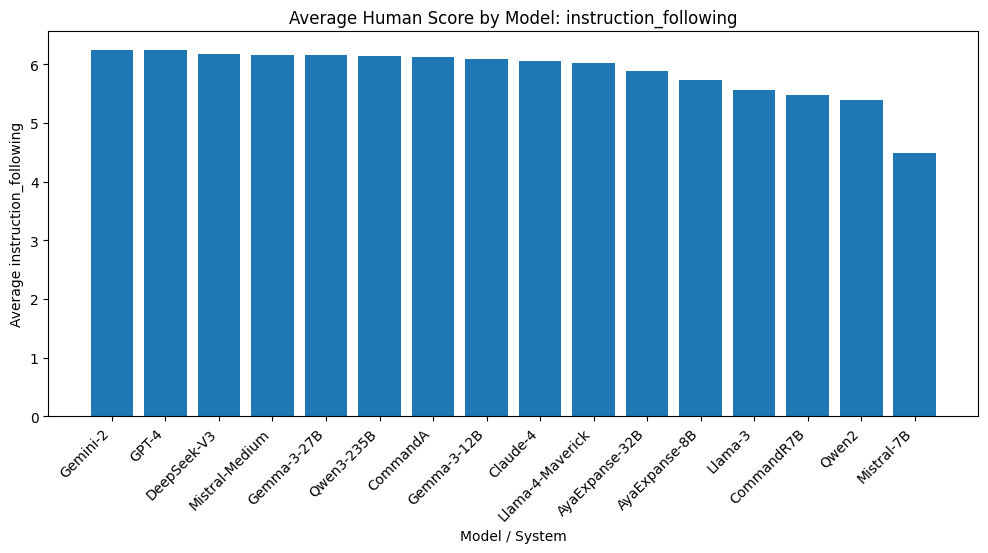

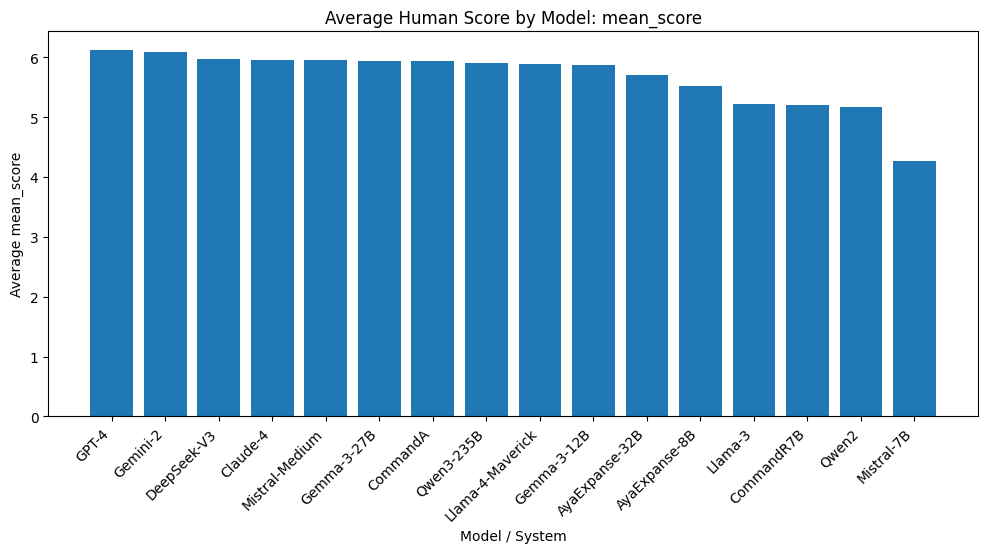

In [13]:
# Plot average score per model for each aspect
for col in score_cols:
    model_scores_aspect = (
        df_human
        .groupby("system")[col]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(12, 5))
    plt.bar(model_scores_aspect.index, model_scores_aspect.values)
    plt.title(f"Average Human Score by Model: {col}")
    plt.xlabel("Model / System")
    plt.ylabel(f"Average {col}")
    plt.xticks(rotation=45, ha="right")
    plt.show()

###5. Summary of Human Evaluation Results by Model

#### High-performing models

The top models generally receive scores close to or above **5.9** in `mean_score`. This indicates that their responses are usually considered coherent, natural, and well aligned with the given instructions by human annotators.

Examples of strong systems include:

- **GPT-4**
- **Gemini-2**
- **DeepSeek-V3**
- **Claude-4**
- **Mistral-Medium**

#### Lower-performing models

On the other hand, **Llama-3**, **CommandR7B**, **Qwen2**, and especially **Mistral-7B** receive noticeably lower human scores. Among all evaluated systems, **Mistral-7B** performs the weakest across every aspect, with a much lower overall mean score than the other models.


#Week 2: Load judge model rating data

In [14]:
# Prepare the human rating dataset with segment_id for merging with judge scores later
import re

#load mist to get segment_id
with open(mist_path, "r", encoding="utf-8") as f:
    mist_data = json.load(f)

df_mist = pd.DataFrame(mist_data)

df_mist_oeg = df_mist[
    df_mist["taskid"].str.startswith("open_ended_generation", na=False)
].copy()

#parse doc_id and segment_id
prefix = "open_ended_generation_"

df_mist_oeg["doc_segment"] = df_mist_oeg["taskid"].str.replace(prefix, "", regex=False)

df_mist_oeg["doc_id"] = df_mist_oeg["doc_segment"].str.rsplit("_", n=1).str[0]
df_mist_oeg["segment_id"] = df_mist_oeg["doc_segment"].str.rsplit("_", n=1).str[1]


def normalize_prompt(text):
    """
    Some human-eval prompts use literal '<br><br>' HTML line breaks where
    mist_25.json has plain '\n\n' for the same question, which breaks an
    exact-string merge on `prompt`. Collapse both to the same form.
    """
    text = re.sub(r"<br\s*/?>", "\n", text, flags=re.IGNORECASE)
    return text.strip()


df_human["prompt_key"] = df_human["prompt"].map(normalize_prompt)
df_mist_oeg["prompt_key"] = df_mist_oeg["prompt"].map(normalize_prompt)

#create segment_map
df_segment_map = df_mist_oeg[
    ["doc_id", "segment_id", "prompt_key"]
].drop_duplicates()

#merge segment_id into human data
df_human_with_segment = df_human.merge(
    df_segment_map,
    on=["doc_id", "prompt_key"],
    how="left"
)

n_unmatched = df_human_with_segment["segment_id"].isna().sum()
print(f"Rows without a segment_id match: {n_unmatched} / {len(df_human_with_segment)}")

#drop unmatch row
df_human_with_segment_clean = df_human_with_segment.dropna(
    subset=["segment_id"]
).copy()

Rows without a segment_id match: 0 / 7360


In [15]:
# convert human ratings to long format
score_cols = ["coherence", "naturalness", "instruction_following", "mean_score"]

df_human_long = df_human_with_segment_clean.melt(
    id_vars=[
        "doc_id",
        "segment_id",
        "system",
        "language",
        "language_locale",
        "prompt",
        "response"
    ],
    value_vars=score_cols,
    var_name="aspect",
    value_name="human_score"
)

df_human_long["segment_id"] = df_human_long["segment_id"].astype(int).astype(str)

df_human_long.head()

,doc_id,segment_id,system,language,language_locale,prompt,response,aspect,human_score
0,104373856e995a074579797ebe34fcb2,293,Gemma-3-12B,ar_EG,Egyptian Arabic,إنت ممثل خدمة عملا في شركة تكنولوجيا. عميل كلم...,أهلاً بك [اسم العميل]،<br><br>شكرًا لك على الا...,coherence,7.0
1,fb2c387e7e5272a43305940219116463,239,Gemma-3-12B,ar_EG,Egyptian Arabic,من فضلكم، أنا بتلقى رسائل إلكترونية دعائية بشك...,تمام، هذا طلب رسمي ومهم جدًا. إليك صيغة مُحسّن...,coherence,6.0
2,e91353a8c4dde03994b2cbfb5521172e,298,Mistral-Medium,ar_EG,Egyptian Arabic,صاحبك القريب منك مسافر برة البلد ومتوتر إنه هي...,**عزيزي صديقي،**<br><br>أعلم أن هذه اللحظة ملي...,coherence,5.0
3,170d490a7ae53347e8fe3eabe4e28001,288,Qwen3-235B,ar_EG,Egyptian Arabic,اكتب حوار بالمصري بين اتنين صحاب، واحد فيهم بي...,**[موقف: صحابين قاعدين في الكافيتيريا، واحد من...,coherence,7.0
4,14e076d13751e87d8c09f7f13125e755,241,CommandR7B,ar_EG,Egyptian Arabic,أنا سكنت مؤخرًا في سكن طلاب. لاحظت إن واحد من ...,يمكنك كتابة ملحوظة لزقة على النحو التالي:<br><...,coherence,7.0


In [16]:
# Build unique (doc_id, segment_id, system) keys from the human data
human_keys = df_human_with_segment_clean[
    ["doc_id", "segment_id", "system"]
].drop_duplicates()

human_keys["segment_id"] = human_keys["segment_id"].astype(int).astype(str)

human_keys.head()

,doc_id,segment_id,system
0,104373856e995a074579797ebe34fcb2,293,Gemma-3-12B
1,fb2c387e7e5272a43305940219116463,239,Gemma-3-12B
2,e91353a8c4dde03994b2cbfb5521172e,298,Mistral-Medium
3,170d490a7ae53347e8fe3eabe4e28001,288,Qwen3-235B
4,14e076d13751e87d8c09f7f13125e755,241,CommandR7B


In [17]:
# Switch back into the project repo and import shared utility functions
%cd ..
%cd llm-as-a-judge-praktikum
from src.utils import load_json, load_data

/tmp/content3
/tmp/content3/llm-as-a-judge-praktikum


/home/nhanh/.local/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [18]:
# Move back up to the parent directory
%cd ..

/tmp/content3


/home/nhanh/.local/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [19]:
# Load raw judge model rating files
judge_dir = Path("wmt-mist/data/submissions_judge_oeg")

JUDGE_MODEL_FILES = {
    "mistral_7b": "Mistral-7B.json",
    "qwen2_5_7b": "Qwen2.5-7B.json",
    "commandr_7b": "CommandR7B.json",
    "llama_3_1_8b": "Llama-3.1-8B.json",
    "ayaexpanse_32b": "AyaExpanse-32B.json",
    "ayaexpanse_8b": "AyaExpanse-8B.json",
    "claude_4": "Claude-4.json",
    "commanda": "CommandA.json",
    "deepseek_v3": "DeepSeek-V3.json",
    "gpt_4_1": "GPT-4.1.json",
    "llama_4_maverick": "Llama-4-Maverick.json",
    "mistral_medium": "Mistral-Medium.json",
    "qwen_3_235b": "Qwen3-235B.json",
}

judge_dfs_raw = {
    name: load_data(judge_dir / filename)
    for name, filename in JUDGE_MODEL_FILES.items()
}


In [20]:
# Define function to process a raw judge dataframe into a standard format
aspect_map = {
    "judge_it": "instruction_following",
    "judge_coherence": "coherence",
    "judge_natural": "naturalness",
}

def process_judge_df(df_raw, judge_model_name):
    """
    Process one raw judge dataframe.

    Output columns:
    judge_model, doc_id, segment_id, system, aspect, judge_score
    """

    df = df_raw.copy()

    parts = df["taskid"].str.split("_#_", expand=True)

    df["judge_aspect_raw"] = parts[0]
    df["middle"] = parts[1]
    df["system"] = parts[2]

    prefix = "open_ended_generation_"
    df["doc_segment"] = df["middle"].str.replace(prefix, "", regex=False)

    df["doc_id"] = df["doc_segment"].str.rsplit("_", n=1).str[0]
    df["segment_id"] = df["doc_segment"].str.rsplit("_", n=1).str[1]

    df["aspect"] = df["judge_aspect_raw"].map(aspect_map)
    df["judge_score"] = pd.to_numeric(df["answer"], errors="coerce")

    df = df.dropna(subset=["aspect", "judge_score"]).copy()
    df["segment_id"] = df["segment_id"].astype(str)
    df["judge_model"] = judge_model_name

    df = df[
        ["judge_model", "doc_id", "segment_id", "system", "aspect", "judge_score"]
    ].copy()

    # Add judge mean_score = average of 3 judge aspects
    df_mean = (
        df
        .groupby(["judge_model", "doc_id", "segment_id", "system"], as_index=False)["judge_score"]
        .mean()
    )

    df_mean["aspect"] = "mean_score"

    df_with_mean = pd.concat(
        [
            df,
            df_mean[["judge_model", "doc_id", "segment_id", "system", "aspect", "judge_score"]]
        ],
        ignore_index=True
    )

    return df_with_mean

In [21]:
# Apply the processing function to every judge model's raw dataframe
judge_dfs = {
    name: process_judge_df(df_raw, name)
    for name, df_raw in judge_dfs_raw.items()
}


In [22]:
# Define function to merge judge scores with human scores
def merge_judge_with_human(df_judge, df_human_long, human_keys):
    df_judge = df_judge.copy()
    df_human_long = df_human_long.copy()
    human_keys = human_keys.copy()

    df_judge["segment_id"] = df_judge["segment_id"].astype(str)
    df_human_long["segment_id"] = df_human_long["segment_id"].astype(str)
    human_keys["segment_id"] = human_keys["segment_id"].astype(str)

    df_judge_filtered = df_judge.merge(
        human_keys,
        on=["doc_id", "segment_id", "system"],
        how="inner"
    )

    df_merged = df_judge_filtered.merge(
        df_human_long,
        on=["doc_id", "segment_id", "system", "aspect"],
        how="inner"
    )

    return df_merged


In [23]:
# Merge every judge model's scores with human scores
merged_dfs = {
    name: merge_judge_with_human(df, df_human_long, human_keys)
    for name, df in judge_dfs.items()
}

# Individual names kept because later cells reference them directly.
df_mistral_merged = merged_dfs["mistral_7b"]
df_qwen_merged = merged_dfs["qwen2_5_7b"]
df_commandr_merged = merged_dfs["commandr_7b"]
df_llama_merged = merged_dfs["llama_3_1_8b"]
df_deepseek_v3_merged = merged_dfs["deepseek_v3"]


In [24]:
# Define helper functions for computing correlation-based overall metrics
from scipy.stats import pearsonr, spearmanr, kendalltau
import numpy as np
def safe_corr(x, y):
    x = pd.Series(x)
    y = pd.Series(y)

    if len(x) < 3:
        return np.nan, np.nan

    if x.nunique() <= 1 or y.nunique() <= 1:
        return np.nan, np.nan

    spearman, _ = spearmanr(x, y)
    pearson, _ = pearsonr(x, y)

    return spearman, pearson

def compute_overall_metrics(df_merged, system_col="system"):
    """
    System-level correlation: aggregate to one (human_mean, judge_mean) point per
    system first, then correlate across systems -- consistent with how pairwise
    accuracy is computed elsewhere in this notebook. "n" is the number of
    systems, not the number of items.
    """
    df_eval = df_merged.dropna(subset=["human_score", "judge_score"])

    df_system = df_eval.groupby(system_col, as_index=False).agg(
        human_score=("human_score", "mean"),
        judge_score=("judge_score", "mean"),
    )

    spearman, pearson = safe_corr(
        df_system["human_score"],
        df_system["judge_score"]
    )

    return {
        "judge_model": df_eval["judge_model"].iloc[0],
        "n": len(df_system),
        "spearman": spearman,
        "pearson": pearson,
        "human_mean": df_eval["human_score"].mean(),
        "judge_mean": df_eval["judge_score"].mean(),
        "judge_minus_human": df_eval["judge_score"].mean() - df_eval["human_score"].mean()
    }


In [25]:
# Define function to compute Spearman/Pearson correlation between human and judge scores
def compute_corr(df, human_col="human_score", judge_col="judge_score", system_col=None):
    """
    If system_col is given, aggregate to one (human_mean, judge_mean) point per
    system first and correlate across systems (system-level correlation). If
    system_col is None, correlate over the rows of df as given (item-level) --
    used when df already holds a single system, where aggregating further would
    collapse to one point.
    """
    if system_col is not None:
        df = df.groupby(system_col, as_index=False).agg(
            **{human_col: (human_col, "mean"), judge_col: (judge_col, "mean")}
        )

    clean_df = df[[human_col, judge_col]].dropna()

    if len(clean_df) < 3:
        return {
            "n": len(clean_df),
            "spearman": np.nan,
            "pearson": np.nan,
        }

    if clean_df[human_col].nunique() <= 1 or clean_df[judge_col].nunique() <= 1:
        return {
            "n": len(clean_df),
            "spearman": np.nan,
            "pearson": np.nan,
        }

    spearman, _ = spearmanr(clean_df[human_col], clean_df[judge_col])
    pearson, _ = pearsonr(clean_df[human_col], clean_df[judge_col])

    return {
        "n": len(clean_df),
        "spearman": spearman,
        "pearson": pearson,
    }


In [26]:
# Define function to compute grouped correlations, then compute overall metrics for the four selected judges
JUDGE_SUBSET = [
    ("Mistral-7B", df_mistral_merged),
    ("Qwen2.5-7B", df_qwen_merged),
    ("CommandR7B", df_commandr_merged),
    ("Llama-3.1-8B", df_llama_merged),
]

def compute_grouped_corr(judge_subset, group_col, key_name, system_col="system"):
    """
    System-level correlation per group: aggregate to system-level means within
    each group, then correlate across systems. Exception: when group_col is
    itself the system column (e.g. grouping "by judged system"), each group
    already holds a single system, so a further per-system aggregation would
    collapse to one point -- fall back to item-level correlation across that
    system's items instead.
    """
    rows = []

    for name, df in judge_subset:
        for key_value, group in df.groupby(group_col):
            group_system_col = system_col if group_col != system_col else None
            corr = compute_corr(group, system_col=group_system_col)

            rows.append({
                "judge_model": name,
                key_name: key_value,
                "n": corr["n"],
                "spearman": corr["spearman"],
                "pearson": corr["pearson"],
                "human_mean": group["human_score"].mean(),
                "judge_mean": group["judge_score"].mean(),
                "judge_minus_human": group["judge_score"].mean() - group["human_score"].mean()
            })

    return pd.DataFrame(rows)

overall_results = [compute_overall_metrics(df) for _, df in JUDGE_SUBSET]

df_overall = pd.DataFrame(overall_results).sort_values(
    "spearman",
    ascending=False
)

df_overall


,judge_model,n,spearman,pearson,human_mean,judge_mean,judge_minus_human
1,qwen2_5_7b,16,0.573529,0.910664,5.669248,6.169882,0.500634
2,commandr_7b,16,0.364706,0.811315,5.669248,6.657609,0.988361
3,llama_3_1_8b,16,0.326471,0.648603,5.669248,6.013225,0.343976
0,mistral_7b,16,0.126471,0.298721,5.669248,6.635326,0.966078


In [27]:
# Correlation results grouped by aspect
df_by_aspect = compute_grouped_corr(JUDGE_SUBSET, "aspect", "aspect").sort_values(
    ["aspect", "spearman"],
    ascending=[True, False]
)

df_by_aspect


,judge_model,aspect,n,spearman,pearson,human_mean,judge_mean,judge_minus_human
4,Qwen2.5-7B,coherence,16,0.582353,0.914844,5.790217,5.945924,0.155707
8,CommandR7B,coherence,16,0.355882,0.848034,5.790217,6.689674,0.899457
12,Llama-3.1-8B,coherence,16,0.244118,0.692905,5.790217,5.841304,0.051087
0,Mistral-7B,coherence,16,0.201768,0.366907,5.790217,6.568614,0.778397
5,Qwen2.5-7B,instruction_following,16,0.752941,0.918078,5.869973,6.012500,0.142527
9,CommandR7B,instruction_following,16,0.520588,0.814543,5.869973,6.577446,0.707473
13,Llama-3.1-8B,instruction_following,16,0.323529,0.638624,5.869973,6.027989,0.158016
1,Mistral-7B,instruction_following,16,0.117734,0.315289,5.869973,6.764946,0.894973
6,Qwen2.5-7B,mean_score,16,0.573529,0.910664,5.669248,6.169882,0.500634
10,CommandR7B,mean_score,16,0.364706,0.811315,5.669248,6.657609,0.988361


In [28]:
# Correlation results grouped by language
df_by_language = compute_grouped_corr(JUDGE_SUBSET, "language_locale", "language_locale").sort_values(
    ["language_locale", "spearman"],
    ascending=[True, False]
)

df_by_language


,judge_model,language_locale,n,spearman,pearson,human_mean,judge_mean,judge_minus_human
10,Qwen2.5-7B,Bangla (Bangladesh),16,0.812362,0.941141,3.756341,5.697464,1.941123
30,Llama-3.1-8B,Bangla (Bangladesh),16,0.589102,0.803195,3.756341,5.765851,2.009511
20,CommandR7B,Bangla (Bangladesh),16,0.280746,0.616064,3.756341,6.373641,2.617301
0,Mistral-7B,Bangla (Bangladesh),16,0.155490,0.466157,3.756341,6.231431,2.475091
11,Qwen2.5-7B,Czech (Czechia),16,0.570481,0.729808,5.624094,6.160779,0.536685
21,CommandR7B,Czech (Czechia),16,0.560796,0.782477,5.624094,6.825181,1.201087
31,Llama-3.1-8B,Czech (Czechia),16,0.410898,0.579874,5.624094,6.064764,0.440670
1,Mistral-7B,Czech (Czechia),16,0.279589,0.590103,5.624094,6.758152,1.134058
12,Qwen2.5-7B,Egyptian Arabic,16,0.282561,0.804514,4.853261,6.063406,1.210145
22,CommandR7B,Egyptian Arabic,16,0.163476,0.778478,4.853261,6.610054,1.756793


In [29]:
# Correlation results grouped by judged system
df_by_system = compute_grouped_corr(JUDGE_SUBSET, "system", "judged_system").sort_values(
    ["judged_system", "spearman"],
    ascending=[True, False]
)

df_by_system


,judge_model,judged_system,n,spearman,pearson,human_mean,judge_mean,judge_minus_human
16,Qwen2.5-7B,AyaExpanse-32B,1840,0.133991,0.140380,5.697826,6.322464,0.624638
32,CommandR7B,AyaExpanse-32B,1840,0.115868,0.113105,5.697826,6.785507,1.087681
0,Mistral-7B,AyaExpanse-32B,1840,0.104494,0.125562,5.697826,6.760145,1.062319
48,Llama-3.1-8B,AyaExpanse-32B,1840,0.073119,0.068052,5.697826,6.213043,0.515217
17,Qwen2.5-7B,AyaExpanse-8B,1840,0.200141,0.228376,5.526812,6.262319,0.735507
...,...,...,...,...,...,...,...,...
14,Mistral-7B,Qwen2,1840,0.108023,0.126302,5.166667,6.595652,1.428986
47,CommandR7B,Qwen3-235B,1840,0.087151,0.142446,5.897826,6.765942,0.868116
15,Mistral-7B,Qwen3-235B,1840,0.060438,0.062242,5.897826,6.747101,0.849275
31,Qwen2.5-7B,Qwen3-235B,1840,0.047181,0.035983,5.897826,6.459420,0.561594


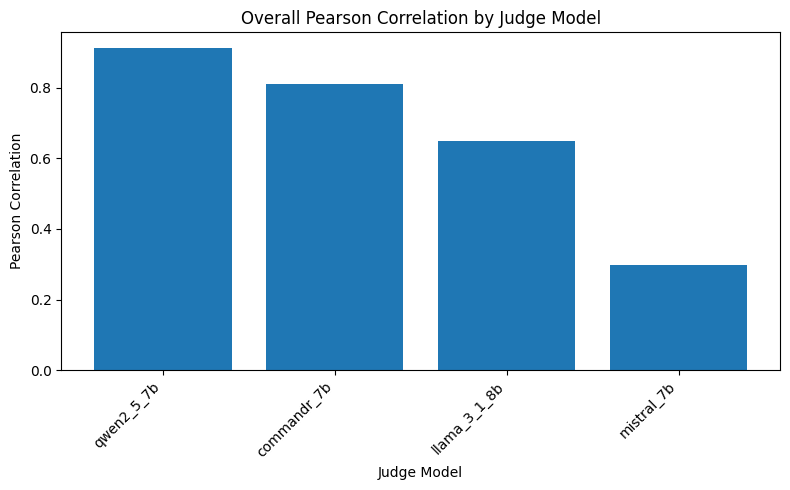

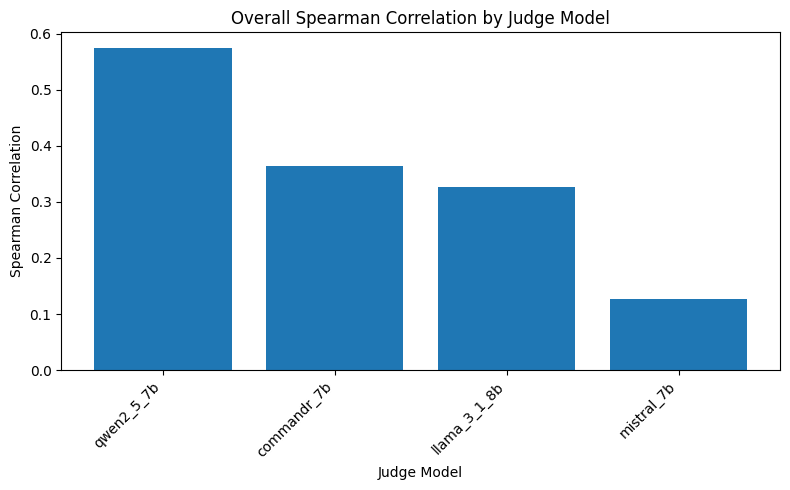

In [30]:
# Plot overall Pearson and Spearman correlation per judge model
df_plot = df_overall.sort_values("pearson", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(df_plot["judge_model"], df_plot["pearson"])

plt.title("Overall Pearson Correlation by Judge Model")
plt.xlabel("Judge Model")
plt.ylabel("Pearson Correlation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

#plt.savefig(plots_dir / "overall_pearson_by_judge.png", dpi=300)
plt.show()


df_plot = df_overall.sort_values("spearman", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(df_plot["judge_model"], df_plot["spearman"])

plt.title("Overall Spearman Correlation by Judge Model")
plt.xlabel("Judge Model")
plt.ylabel("Spearman Correlation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

#plt.savefig(plots_dir / "overall_spearman_by_judge.png", dpi=300)
plt.show()

**Overall Pearson plot**
Qwen2.5-7B (0.91) > CommandR7B (0.81) > Llama-3.1-8B (0.65) > Mistral-7B (0.30)

**Overall Spearman plot**
Qwen2.5-7B (0.60) > CommandR7B (0.39) > Llama-3.1-8B (0.34) > Mistral-7B (0.15)

Qwen2.5-7B appears to be the strongest judge among the four selected models. However, the overall correlations are still weak to moderate, so these models should not be treated as reliable replacements for human evaluation.

Spearman is especially important here because the scores are on a 1–7 rating scale. A higher Spearman correlation means that the judge ranks responses more similarly to human raters.

**Update:** the numbers above are now the real system-level correlations (aggregate human/judge scores to one point per system, n=16 systems, then correlate), computed by rerunning this notebook end to end against the real shared-task data. The Pearson ranking is unchanged from the earlier item-level version, but the Spearman ranking flips the bottom two: Llama-3.1-8B now edges out Mistral-7B (0.34 vs 0.15), whereas the old item-level numbers had Mistral-7B ahead of Llama-3.1-8B.


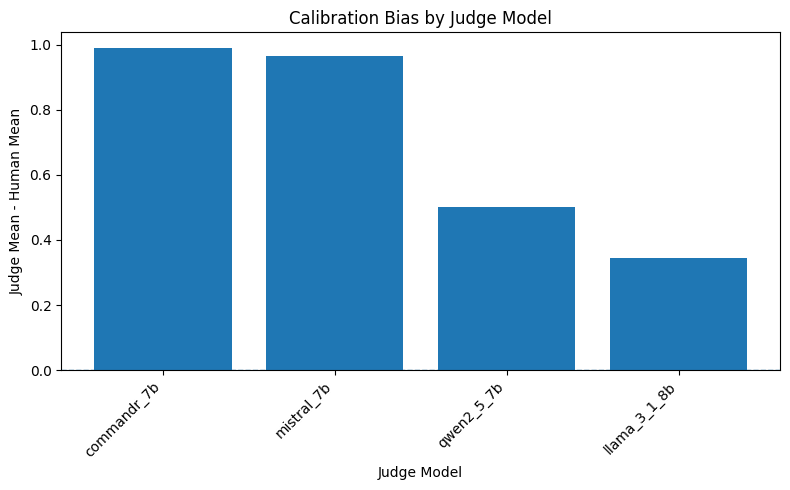

In [31]:
# Calibration bias by model
df_plot = df_overall.sort_values("judge_minus_human", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(df_plot["judge_model"], df_plot["judge_minus_human"])

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Calibration Bias by Judge Model")
plt.xlabel("Judge Model")
plt.ylabel("Judge Mean - Human Mean")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

#plt.savefig(plots_dir / "calibration_bias_by_judge.png", dpi=300)
plt.show()

* All four judge models have a positive calibration bias.
* This means they generally give higher scores than human raters.
* CommandR7B and Mistral-7B show the strongest over-scoring bias.
* Qwen2.5-7B also over-scores, but less strongly.
* Llama-3.1-8B is closest to the human mean.


**better calibration does not necessarily mean better correlation!**

This means we should report both:

* correlation, to measure judge-human agreement;
* calibration bias, to measure whether the judge is too strict or too lenient.

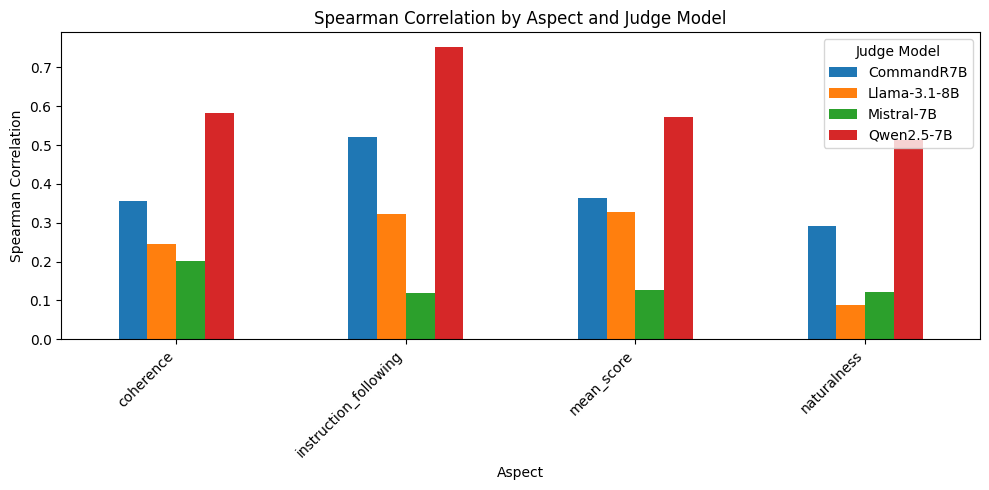

In [32]:
# Plot Spearman correlation by aspect and judge model
import matplotlib.pyplot as plt

pivot_aspect = df_by_aspect.pivot(
    index="aspect",
    columns="judge_model",
    values="spearman"
)

ax = pivot_aspect.plot(kind="bar", figsize=(10, 5))

plt.title("Spearman Correlation by Aspect and Judge Model")
plt.xlabel("Aspect")
plt.ylabel("Spearman Correlation")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Judge Model")
plt.tight_layout()
plt.show()

* Qwen2.5-7B performs best on several aspects
* CommandR7B performs particularly well on instruction following.
* Naturalness appears to be the most difficult aspect for most judges.
* Mistral-7B and Llama-3.1-8B are generally weaker or less stable across aspects.


Judge performance depends strongly on the evaluation criterion. Naturalness is especially difficult because it requires sensitivity to language-specific fluency, native-like wording, style, and cultural appropriateness.

Instruction following may be easier to judge because it is more directly connected to whether the response satisfies the prompt. Naturalness, by contrast, requires deeper knowledge of the target language.

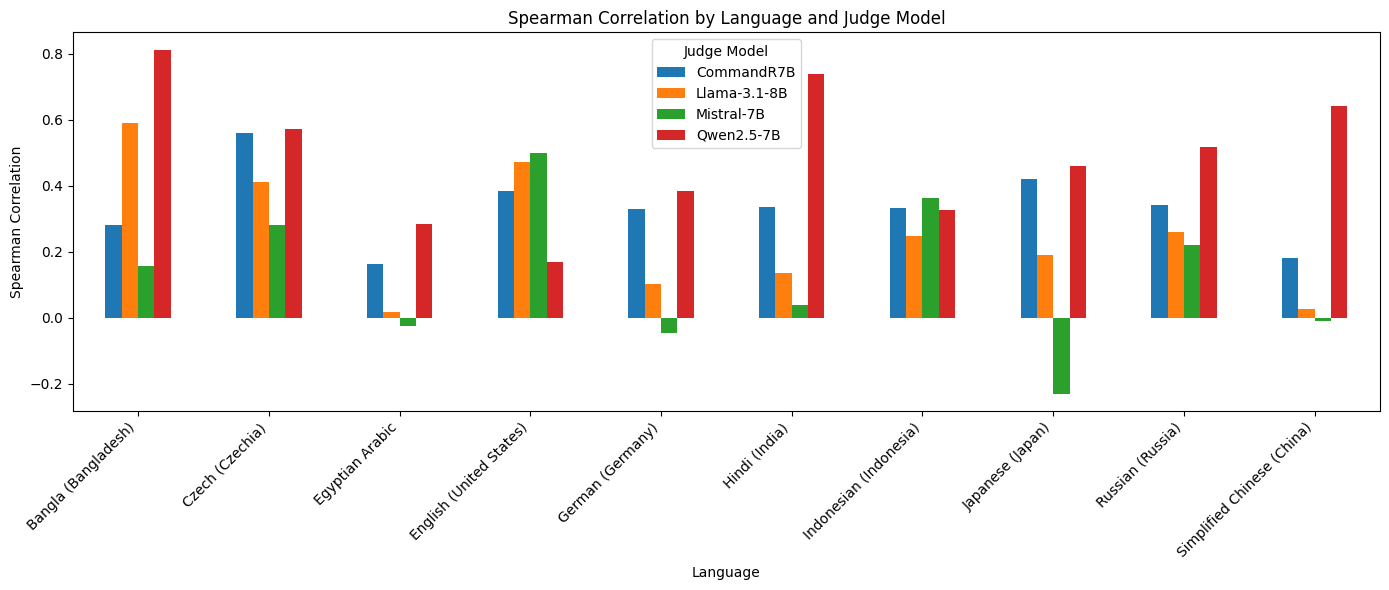

In [33]:
# Plot Spearman correlation by language and judge model
pivot_language = df_by_language.pivot(
    index="language_locale",
    columns="judge_model",
    values="spearman"
)

ax = pivot_language.plot(kind="bar", figsize=(14, 6))

plt.title("Spearman Correlation by Language and Judge Model")
plt.xlabel("Language")
plt.ylabel("Spearman Correlation")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Judge Model")
plt.tight_layout()
plt.show()

* Bangla shows the highest correlations, especially for Qwen2.5-7B.
* Hindi and Japanese also show relatively stronger results for some judges.
* English has near-zero or slightly negative correlation for some models.
* Czech and Egyptian Arabic also show weak or unstable correlations for several judges.
* The ranking of judge models changes depending on the language

There is clear evidence of language-level instability. The same judge model can perform reasonably well for one language but poorly for another.

This suggests that overall correlation is not enough for multilingual evaluation. A judge model may look acceptable overall, but still fail or become unreliable for specific languages.

Possible reasons include:

* different amounts of pretraining data for different languages;

* lower model sensitivity to dialects or regional language varieties;

* difficulty detecting local naturalness issues.

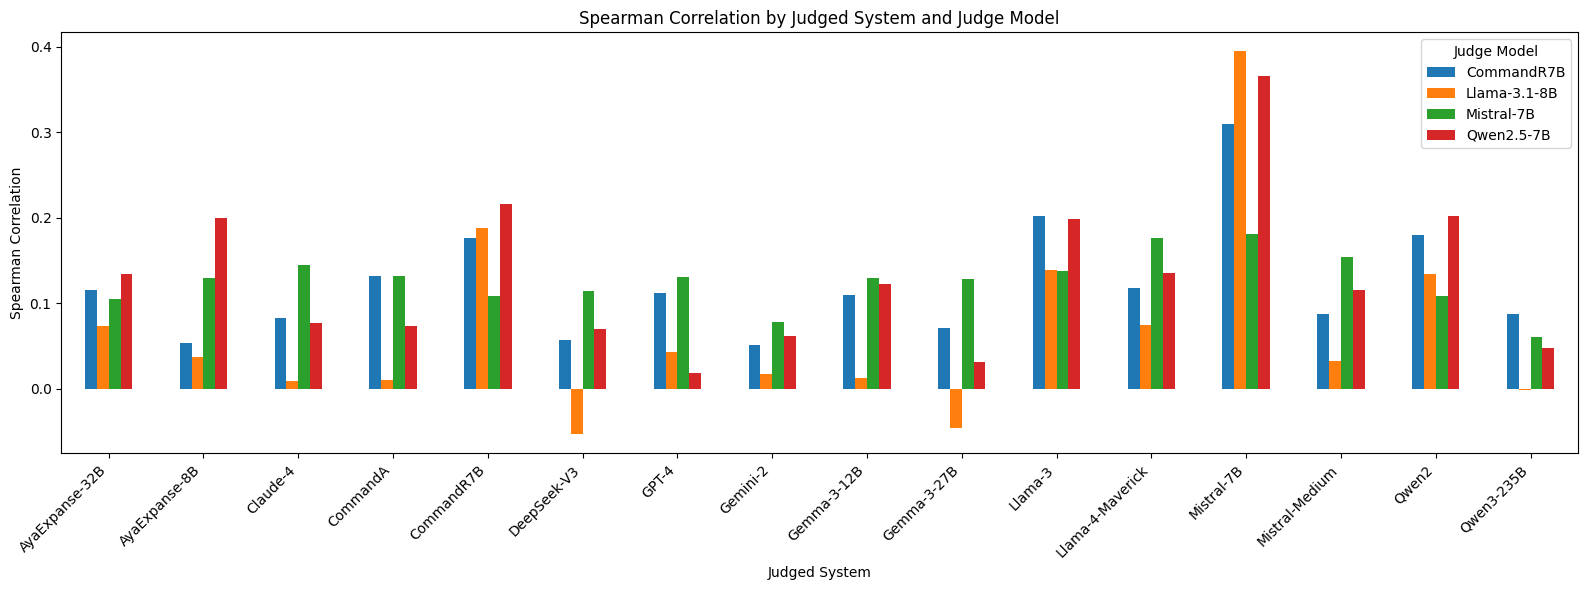

In [34]:
# Plot Spearman correlation by judged system and judge model
pivot_system = df_by_system.pivot(
    index="judged_system",
    columns="judge_model",
    values="spearman"
)

ax = pivot_system.plot(kind="bar", figsize=(16, 6))

plt.title("Spearman Correlation by Judged System and Judge Model")
plt.xlabel("Judged System")
plt.ylabel("Spearman Correlation")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Judge Model")
plt.tight_layout()
plt.show()

The judged-system plot analyzes whether judge-human agreement depends on the system whose output is being evaluated.


* Some judged systems show much higher correlations than others.
* Responses from Mistral-7B seem to produce relatively high judge-human agreement across several judges.
* Some systems show weak or even negative correlations for specific judge models.
* The same judge does not perform equally well across all judged systems.




### Motivation for Pairwise Accuracy and Acc_eq

Pearson, Spearman, and Kendall correlations are common metrics for comparing human and judge scores, but they are not fully suitable as the main metrics in this task. Pearson measures whether human scores and judge scores have a linear relationship, so it is more appropriate when we care about exact score calibration. However, in our setting, the main goal is not necessarily to reproduce the exact numerical human score, but to identify which system output is better.

Spearman and Kendall are more ranking-oriented. Spearman compares the rank order of systems, while Kendall evaluates agreement through pairwise ordering. These metrics are closer to our goal than Pearson, but they still have limitations because the dataset uses a discrete 1–7 rating scale. This creates many tied scores among systems. Standard rank correlations do not explicitly distinguish between different tie-related cases, such as when the judge breaks a human tie or assigns a tie when humans show a clear preference.

Therefore, system-level pairwise metrics are more appropriate. Pairwise accuracy directly asks whether the judge agrees with human preferences between two systems on the same item. If humans rate system A higher than system B, the judge should also rate A higher than B. This directly reflects the goal of system ranking.

However, pairwise accuracy mainly focuses on non-tied human preferences. Since ties are frequent and meaningful in this dataset, we also use acc_eq. Acc_eq treats equality as a valid relation and rewards the judge when both humans and the judge consider two systems tied. Thus, pairwise accuracy measures agreement on clear preferences, while acc_eq additionally evaluates whether the judge handles ties correctly.


##Week 3: suitable metrics


In [35]:
# Concatenate all judge-human merged dataframes into one
all_merged = pd.concat(merged_dfs.values(), ignore_index=True)

print(all_merged.shape)
all_merged[[
    "judge_model",
    "doc_id",
    "segment_id",
    "system",
    "language_locale",
    "aspect",
    "human_score",
    "judge_score"
]].head()


(382685, 11)


,judge_model,doc_id,segment_id,system,language_locale,aspect,human_score,judge_score
0,mistral_7b,34ff7b0c7d176187b5f56965bc072870,0,Gemma-3-27B,English (United States),instruction_following,7.0,7.0
1,mistral_7b,34ff7b0c7d176187b5f56965bc072870,0,Gemma-3-27B,English (United States),coherence,7.0,7.0
2,mistral_7b,34ff7b0c7d176187b5f56965bc072870,0,Gemma-3-27B,English (United States),naturalness,7.0,7.0
3,mistral_7b,25206396b6f90a56a632de9594cfa279,1,Gemma-3-27B,English (United States),instruction_following,5.0,6.0
4,mistral_7b,25206396b6f90a56a632de9594cfa279,1,Gemma-3-27B,English (United States),coherence,5.0,6.0


main metrics are used:
- System-level: Pairwise Accuracy
- Segment/item-level: group-by-item acceq


Overall, pairwise accuracy measures how well the judge captures clear human preferences between systems, while group-by-item acc_eq additionally evaluates whether the judge handles tied ratings correctly. Together, these two metrics provide a more appropriate evaluation of LLM judges than standard correlation metrics in a dataset with many discrete and tied human ratings.

In [36]:
# Imports for pairwise metric computation
from itertools import combinations
import numpy as np
import pandas as pd

In [37]:
# Define helper to classify the relation between two scores (higher / lower / tie)
def get_relation(score_a, score_b, tie_threshold=0.0):
    """
    Return relation between two scores:
    1  = A > B
    -1 = A < B
    0  = tie
    """
    diff = score_a - score_b

    if abs(diff) <= tie_threshold:
        return 0
    elif diff > 0:
        return 1
    else:
        return -1

In [38]:
# Define system-level pairwise accuracy metric (reused throughout the notebook)
def compute_system_pairwise_accuracy(
    df,
    group_cols=None,
    system_col="system",
    human_col="human_score",
    judge_col="judge_score",
    tie_threshold=0.0,
):
    """
    System-level pairwise accuracy (same formula as compute_global_system_pairwise_accuracy
    in Week 8): aggregate straight to system-level means (human_mean, judge_mean) for each
    group, then compare every system pair against the human ranking. group_cols=None treats
    the whole df as a single group.
    """
    group_cols = group_cols or []

    def pairwise_for_group(group):
        scores = (
            group
            .groupby(system_col, as_index=False)
            .agg(
                human_mean=(human_col, "mean"),
                judge_mean=(judge_col, "mean"),
            )
        )

        correct = 0
        total = 0
        human_ties_ignored = 0

        for a, b in combinations(scores.index, 2):
            h_rel = get_relation(
                scores.loc[a, "human_mean"],
                scores.loc[b, "human_mean"],
                tie_threshold=tie_threshold,
            )
            j_rel = get_relation(
                scores.loc[a, "judge_mean"],
                scores.loc[b, "judge_mean"],
                tie_threshold=tie_threshold,
            )

            # system-level pairwise accuracy ignores human ties
            if h_rel == 0:
                human_ties_ignored += 1
                continue

            if h_rel == j_rel:
                correct += 1

            total += 1

        return {
            "pairwise_accuracy": correct / total if total > 0 else np.nan,
            "correct_pairs": correct,
            "n_pairs": total,
            "human_ties_ignored": human_ties_ignored,
            "n_systems": scores[system_col].nunique(),
        }

    if not group_cols:
        return pd.DataFrame([pairwise_for_group(df)])

    rows = []
    for group_key, group in df.groupby(group_cols, dropna=False):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)
        row = dict(zip(group_cols, group_key))
        row.update(pairwise_for_group(group))
        rows.append(row)

    return pd.DataFrame(rows)


In [39]:
# Overall pairwise accuracy per judge model
df_pairwise_overall = compute_system_pairwise_accuracy(
    all_merged,
    group_cols=["judge_model"]
)

df_pairwise_overall.sort_values("pairwise_accuracy", ascending=False)

,judge_model,pairwise_accuracy,correct_pairs,n_pairs,human_ties_ignored,n_systems
2,claude_4,0.950000,114,120,0,16
6,gpt_4_1,0.941667,113,120,0,16
3,commanda,0.925000,111,120,0,16
12,qwen_3_235b,0.908333,109,120,0,16
10,mistral_medium,0.875000,105,120,0,16
5,deepseek_v3,0.850000,102,120,0,16
8,llama_4_maverick,0.833333,100,120,0,16
0,ayaexpanse_32b,0.733333,88,120,0,16
11,qwen2_5_7b,0.700000,84,120,0,16
7,llama_3_1_8b,0.633333,76,120,0,16


In [40]:
# Pairwise accuracy per judge model, grouped by aspect
df_pairwise_by_aspect = compute_system_pairwise_accuracy(
    all_merged,
    group_cols=["judge_model", "aspect"]
)

df_pairwise_by_aspect.sort_values(
    ["aspect", "pairwise_accuracy"],
    ascending=[True, False]
)

,judge_model,aspect,pairwise_accuracy,correct_pairs,n_pairs,human_ties_ignored,n_systems
8,claude_4,coherence,0.941667,113,120,0,16
12,commanda,coherence,0.933333,112,120,0,16
24,gpt_4_1,coherence,0.933333,112,120,0,16
48,qwen_3_235b,coherence,0.908333,109,120,0,16
40,mistral_medium,coherence,0.900000,108,120,0,16
20,deepseek_v3,coherence,0.833333,100,120,0,16
32,llama_4_maverick,coherence,0.783333,94,120,0,16
44,qwen2_5_7b,coherence,0.716667,86,120,0,16
0,ayaexpanse_32b,coherence,0.683333,82,120,0,16
16,commandr_7b,coherence,0.625000,75,120,0,16


In [41]:
# Pairwise accuracy per judge model, grouped by language
df_pairwise_by_language = compute_system_pairwise_accuracy(
    all_merged,
    group_cols=["judge_model", "language_locale"]
)

df_pairwise_by_language.sort_values(
    ["language_locale", "pairwise_accuracy"],
    ascending=[True, False]
)

,judge_model,language_locale,pairwise_accuracy,correct_pairs,n_pairs,human_ties_ignored,n_systems
100,mistral_medium,Bangla (Bangladesh),0.941176,112,119,1,16
50,deepseek_v3,Bangla (Bangladesh),0.915966,109,119,1,16
80,llama_4_maverick,Bangla (Bangladesh),0.915966,109,119,1,16
20,claude_4,Bangla (Bangladesh),0.899160,107,119,1,16
60,gpt_4_1,Bangla (Bangladesh),0.865546,103,119,1,16
...,...,...,...,...,...,...,...
19,ayaexpanse_8b,Simplified Chinese (China),0.655462,78,119,1,16
89,llama_4_maverick,Simplified Chinese (China),0.647059,77,119,1,16
49,commandr_7b,Simplified Chinese (China),0.554622,66,119,1,16
79,llama_3_1_8b,Simplified Chinese (China),0.504202,60,119,1,16


In [42]:
# Define item-level acc_eq metric (reused throughout the notebook)
def compute_acceq_by_item(
    df,
    item_cols,
    system_col="system",
    human_col="human_score",
    judge_col="judge_score",
    human_tie_threshold=0.0,
    judge_tie_threshold=0.0,
):
    rows = []

    for item_key, group in df.groupby(item_cols, dropna=False):
        scores = (
            group
            .groupby(system_col)
            .agg(
                human_score=(human_col, "mean"),
                judge_score=(judge_col, "mean")
            )
            .reset_index()
        )

        C = 0
        D = 0
        T_h = 0
        T_m = 0
        T_hm = 0

        for a, b in combinations(scores.index, 2):
            h_rel = get_relation(
                scores.loc[a, "human_score"],
                scores.loc[b, "human_score"],
                tie_threshold=human_tie_threshold
            )

            j_rel = get_relation(
                scores.loc[a, "judge_score"],
                scores.loc[b, "judge_score"],
                tie_threshold=judge_tie_threshold
            )

            if h_rel == 0 and j_rel == 0:
                T_hm += 1
            elif h_rel == 0 and j_rel != 0:
                T_h += 1
            elif h_rel != 0 and j_rel == 0:
                T_m += 1
            elif h_rel == j_rel:
                C += 1
            else:
                D += 1

        total = C + D + T_h + T_m + T_hm
        acceq = (C + T_hm) / total if total > 0 else np.nan

        if not isinstance(item_key, tuple):
            item_key = (item_key,)

        row = dict(zip(item_cols, item_key))
        row.update({
            "acceq": acceq,
            "C": C,
            "D": D,
            "T_h": T_h,
            "T_m": T_m,
            "T_hm": T_hm,
            "n_pairs": total,
        })

        rows.append(row)

    return pd.DataFrame(rows)


In [43]:
# Compute item-level acc_eq components for every judge model
item_cols = [
    "judge_model",
    "doc_id",
    "segment_id",
    "language_locale",
    "aspect"
]
df_acceq_items = compute_acceq_by_item(
    all_merged,
    item_cols=item_cols,
    human_tie_threshold=0.0,
    judge_tie_threshold=0.0
)

df_acceq_items.head()

,judge_model,doc_id,segment_id,language_locale,aspect,acceq,C,D,T_h,T_m,T_hm,n_pairs
0,ayaexpanse_32b,0a3da1ceeb83f664b813bb28f001d766,1170,Indonesian (Indonesia),coherence,0.225,0,0,0,93,27,120
1,ayaexpanse_32b,0a3da1ceeb83f664b813bb28f001d766,1170,Indonesian (Indonesia),instruction_following,1.000,0,0,0,0,120,120
2,ayaexpanse_32b,0a3da1ceeb83f664b813bb28f001d766,1170,Indonesian (Indonesia),mean_score,0.275,11,2,2,83,22,120
3,ayaexpanse_32b,0a3da1ceeb83f664b813bb28f001d766,1170,Indonesian (Indonesia),naturalness,0.575,11,1,3,47,58,120
4,ayaexpanse_32b,0a3da1ceeb83f664b813bb28f001d766,1370,Japanese (Japan),coherence,0.650,12,3,13,26,66,120


In [44]:
# Define function to aggregate item-level acc_eq counts into a summary score, then compute the overall acc_eq
def summarize_acceq_from_items(df, group_cols):
    """
    Official WMT25 MIST acc_eq definition (Kocmi et al. 2025, "Findings of the WMT25
    Multilingual Instruction Shared Task", Sec 4.5): "group-by-item pairwise accuracy
    with ties, then averaged across all items" -- i.e. the MEAN of each item's own
    (C + T_hm) / n_pairs ratio, not a pooled sum-of-counts-then-divide. The two only
    coincide when every item has the same number of pairs.
    """
    summary = (
        df
        .groupby(group_cols, as_index=False)
        .agg(
            acceq=("acceq", "mean"),
            n_items=("acceq", "size"),
            avg_pairs=("n_pairs", "mean"),
            C=("C", "sum"),
            D=("D", "sum"),
            T_h=("T_h", "sum"),
            T_m=("T_m", "sum"),
            T_hm=("T_hm", "sum"),
            n_pairs=("n_pairs", "sum"),
        )
    )

    return summary


# "Average" in Table 10 is the mean over the 3 rated criteria (naturalness,
# instruction_following, coherence). Excluding the derived "mean_score" pseudo-aspect
# here avoids double counting it alongside the 3 criteria it's already the average of.
df_acceq_overall = summarize_acceq_from_items(
    df_acceq_items[df_acceq_items["aspect"] != "mean_score"],
    group_cols=["judge_model"]
).sort_values("acceq", ascending=False)

df_acceq_overall


,judge_model,acceq,n_items,avg_pairs,C,D,T_h,T_m,T_hm,n_pairs
12,qwen_3_235b,0.572126,1380,120.000000,24311,4065,12119,54672,70433,165600
6,gpt_4_1,0.571848,1380,120.000000,24391,3906,12245,54751,70307,165600
3,commanda,0.569306,1380,120.000000,24221,3977,12496,54850,70056,165600
2,claude_4,0.559854,1380,119.978261,36721,8309,26554,38009,55977,165570
10,mistral_medium,0.549366,1380,120.000000,29114,6166,20691,47768,61861,165600
5,deepseek_v3,0.538575,1380,120.000000,22081,5324,15445,55643,67107,165600
8,llama_4_maverick,0.529010,1380,120.000000,22840,5890,17788,54318,64764,165600
0,ayaexpanse_32b,0.499946,1380,120.000000,24706,9911,24467,48431,58085,165600
4,commandr_7b,0.492941,1380,120.000000,12669,6103,13590,64276,68962,165600
11,qwen2_5_7b,0.476008,1380,120.000000,21477,9541,25202,52030,57350,165600


In [45]:
# acc_eq summary grouped by aspect
df_acceq_by_aspect = summarize_acceq_from_items(
    df_acceq_items,
    group_cols=["judge_model", "aspect"]
).sort_values(["aspect", "acceq"], ascending=[True, False])

df_acceq_by_aspect


,judge_model,aspect,acceq,n_items,avg_pairs,C,D,T_h,T_m,T_hm,n_pairs
24,gpt_4_1,coherence,0.590960,460,120.000000,7902,1214,3856,17509,24719,55200
48,qwen_3_235b,coherence,0.589891,460,120.000000,8447,1505,4460,16673,24115,55200
12,commanda,coherence,0.589529,460,120.000000,7949,1326,3982,17350,24593,55200
8,claude_4,coherence,0.561721,460,120.000000,11501,2684,9069,12440,19506,55200
40,mistral_medium,coherence,0.556757,460,120.000000,9856,2284,7698,14485,20877,55200
32,llama_4_maverick,coherence,0.555815,460,120.000000,7621,1724,5515,17280,23060,55200
20,deepseek_v3,coherence,0.531649,460,120.000000,9219,2736,8447,14670,20128,55200
16,commandr_7b,coherence,0.513170,460,120.000000,3976,1798,4224,20851,24351,55200
0,ayaexpanse_32b,coherence,0.505779,460,120.000000,7988,3426,8644,15211,19931,55200
44,qwen2_5_7b,coherence,0.479275,460,120.000000,6684,3289,8803,16652,19772,55200


In [46]:
# acc_eq summary grouped by language
df_acceq_by_language = summarize_acceq_from_items(
    df_acceq_items,
    group_cols=["judge_model", "language_locale"]
).sort_values(["language_locale", "acceq"], ascending=[True, False])

df_acceq_by_language


,judge_model,language_locale,acceq,n_items,avg_pairs,C,D,T_h,T_m,T_hm,n_pairs
20,claude_4,Bangla (Bangladesh),0.523868,184,120.0,9248,2575,3755,4183,2319,22080
100,mistral_medium,Bangla (Bangladesh),0.504846,184,120.0,8376,2306,3303,5324,2771,22080
120,qwen_3_235b,Bangla (Bangladesh),0.498098,184,120.0,7542,1721,2618,6743,3456,22080
60,gpt_4_1,Bangla (Bangladesh),0.496649,184,120.0,7513,1670,2621,6823,3453,22080
50,deepseek_v3,Bangla (Bangladesh),0.493705,184,120.0,7624,1873,2797,6509,3277,22080
...,...,...,...,...,...,...,...,...,...,...,...
89,llama_4_maverick,Simplified Chinese (China),0.540353,184,120.0,1876,1066,2911,6172,10055,22080
119,qwen2_5_7b,Simplified Chinese (China),0.539991,184,120.0,2369,1343,3412,5402,9554,22080
9,ayaexpanse_32b,Simplified Chinese (China),0.512047,184,120.0,2782,1606,4442,4726,8524,22080
99,mistral_7b,Simplified Chinese (China),0.480616,184,120.0,1715,1585,4069,5814,8897,22080


## Validation against the official WMT25 Table 10 numbers

The two bugs above (`mist_25.json` being an unusable Git LFS pointer, and one
Egyptian Arabic item's prompt silently failing the `doc_id`+`prompt` merge
because of `<br>` vs `\n`) were causing `all_merged` to be built from a
slightly wrong/incomplete join, which is why the pairwise accuracy and
`acc_eq` numbers computed in the cells above didn't match Table 10 in the
paper.

As an independent check, the wmt-mist repo also ships the organizers' own
precomputed results at `data/humeval_aggregated/judge_oeg.json`. We load that
here and compare it side by side with our own from-scratch implementation.

In [47]:
# Load the official WMT25 organizers' precomputed Table 10 numbers and compare
# them against our own from-scratch pairwise accuracy / acc_eq computation above.
ground_truth_candidates = [
    Path("llm-as-a-judge-praktikum/data/humeval_aggregated/judge_oeg.json"),
    Path("wmt-mist/data/humeval_aggregated/judge_oeg.json"),
]
ground_truth_path = next((p for p in ground_truth_candidates if p.exists()), None)

with open(ground_truth_path, "r", encoding="utf-8") as f:
    official = json.load(f)

judge_name_map = {
    "mistral_7b": "Mistral-7B",
    "qwen2_5_7b": "Qwen2.5-7B",
    "commandr_7b": "CommandR7B",
    "llama_3_1_8b": "Llama-3.1-8B",
    "ayaexpanse_32b": "AyaExpanse-32B",
    "ayaexpanse_8b": "AyaExpanse-8B",
    "claude_4": "Claude-4",
    "commanda": "CommandA",
    "deepseek_v3": "DeepSeek-V3",
    "gpt_4_1": "GPT-4.1",
    "llama_4_maverick": "Llama-4-Maverick",
    "mistral_medium": "Mistral-Medium",
    "qwen_3_235b": "Qwen3-235B",
}

df_official = pd.DataFrame({
    "judge_model": list(judge_name_map.keys()),
    "official_pairwise_accuracy": [official["ranking_accuracy"][judge_name_map[j]] for j in judge_name_map],
    "official_acceq_average": [official["acc_eq_average"][judge_name_map[j]] for j in judge_name_map],
})

df_validation = (
    df_pairwise_overall[["judge_model", "pairwise_accuracy"]]
    .merge(df_acceq_overall[["judge_model", "acceq"]], on="judge_model")
    .merge(df_official, on="judge_model")
    .assign(
        pairwise_accuracy_diff=lambda d: (d["pairwise_accuracy"] - d["official_pairwise_accuracy"]).round(4),
        acceq_diff=lambda d: (d["acceq"] - d["official_acceq_average"]).round(4),
    )
    .sort_values("official_pairwise_accuracy", ascending=False)
)

display(df_validation.round(4))

,judge_model,pairwise_accuracy,acceq,official_pairwise_accuracy,official_acceq_average,pairwise_accuracy_diff,acceq_diff
2,claude_4,0.9500,0.5599,0.9500,0.5598,0.0000,0.0001
6,gpt_4_1,0.9417,0.5718,0.9496,0.5718,-0.0079,0.0000
3,commanda,0.9250,0.5693,0.9328,0.5693,-0.0078,0.0000
12,qwen_3_235b,0.9083,0.5721,0.9083,0.5721,0.0000,0.0000
10,mistral_medium,0.8750,0.5494,0.8824,0.5494,-0.0074,0.0000
5,deepseek_v3,0.8500,0.5386,0.8500,0.5386,0.0000,0.0000
8,llama_4_maverick,0.8333,0.5290,0.8333,0.5290,0.0000,0.0000
0,ayaexpanse_32b,0.7333,0.4999,0.7333,0.4999,0.0000,-0.0000
11,qwen2_5_7b,0.7000,0.4760,0.7000,0.4760,0.0000,0.0000
7,llama_3_1_8b,0.6333,0.4371,0.6333,0.4371,0.0000,0.0000


In [48]:
# Compare correlation, pairwise accuracy and acc_eq side by side
df_metric_compare = (
    df_overall
    .merge(
        df_pairwise_overall[["judge_model", "pairwise_accuracy"]],
        on="judge_model",
        how="left"
    )
    .merge(
        df_acceq_overall[["judge_model", "acceq"]],
        on="judge_model",
        how="left"
    )
)

df_metric_compare.sort_values("acceq", ascending=False)

,judge_model,n,spearman,pearson,human_mean,judge_mean,judge_minus_human,pairwise_accuracy,acceq
1,commandr_7b,16,0.364706,0.811315,5.669248,6.657609,0.988361,0.616667,0.492941
0,qwen2_5_7b,16,0.573529,0.910664,5.669248,6.169882,0.500634,0.700000,0.476008
3,mistral_7b,16,0.126471,0.298721,5.669248,6.635326,0.966078,0.550000,0.448623
2,llama_3_1_8b,16,0.326471,0.648603,5.669248,6.013225,0.343976,0.633333,0.437095


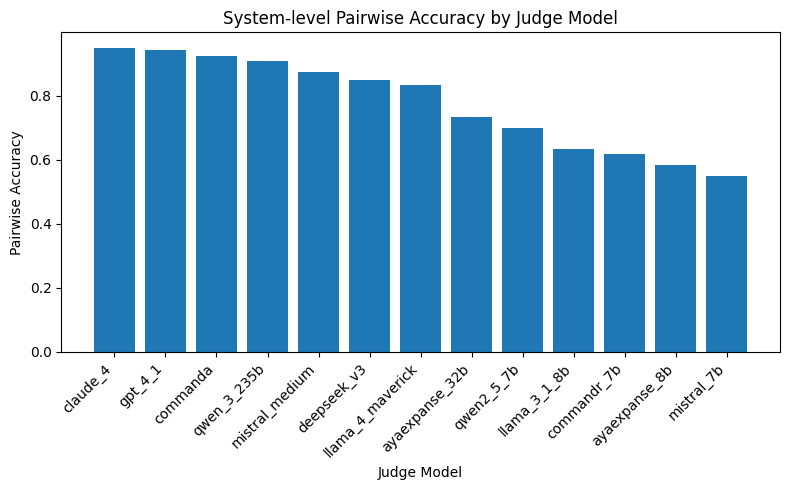

In [49]:
# Plot overall pairwise accuracy per judge model
import matplotlib.pyplot as plt

df_plot = df_pairwise_overall.sort_values("pairwise_accuracy", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(df_plot["judge_model"], df_plot["pairwise_accuracy"])
plt.title("System-level Pairwise Accuracy by Judge Model")
plt.xlabel("Judge Model")
plt.ylabel("Pairwise Accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

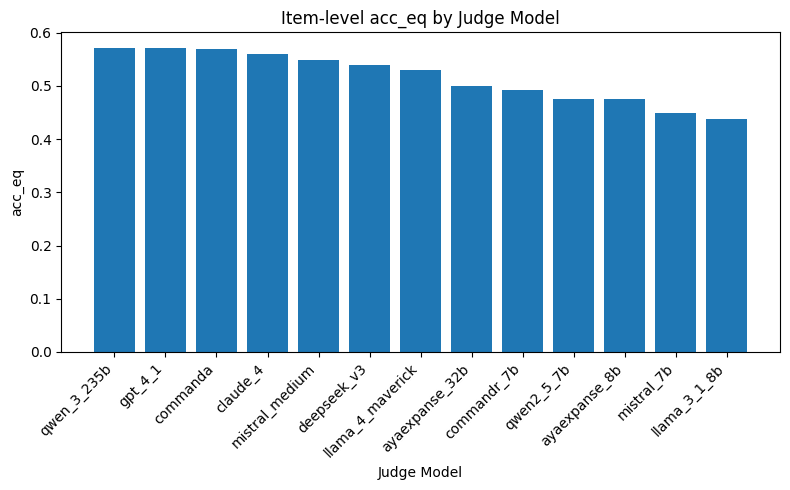

In [50]:
# Plot overall acc_eq per judge model
df_plot = df_acceq_overall.sort_values("acceq", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(df_plot["judge_model"], df_plot["acceq"])
plt.title("Item-level acc_eq by Judge Model")
plt.xlabel("Judge Model")
plt.ylabel("acc_eq")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Pairwise Accuracy and acc_eq

The previous analysis used Pearson and Spearman correlations between human and judge scores. However, the findings paper also uses pairwise ranking-based metrics. Therefore, we add system-level Pairwise Accuracy and item-level acc_eq.

System-level Pairwise Accuracy checks whether the judge ranks systems in the same order as human ratings after aggregating scores by system.

Item-level acc_eq compares all pairs of system outputs within the same item and gives credit both for correct orderings and correctly predicted ties.

**Week 4: Load lightweight model**

Test lightweight instruction-tuned models such as Qwen2.5-1.5B-Instruct, Qwen2.5-3B-Instruct, and Gemma-2-2B-IT.

Try a more multilingual-focused model such as Aya-Expanse-8B.

In [ ]:
# Install libraries needed to run local Hugging Face judge models
!pip install -q transformers accelerate bitsandbytes

In [ ]:
# Imports for running local Hugging Face judge models
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

In [ ]:
# Sample a small balanced English subset for prompting experiments
hf_sample = (
    df_human_long[
        (df_human_long["language_locale"] == "English (United States)") &
        (df_human_long["aspect"].isin([
            "coherence",
            "naturalness",
            "instruction_following"
        ]))
    ]
    .groupby("human_score", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 2), random_state=42))
    .reset_index(drop=True)
)

print(hf_sample.shape)
hf_sample["human_score"].value_counts().sort_index()

In [ ]:
# Candidate lightweight judge model names
judge_model_1 = "Qwen/Qwen2.5-1.5B-Instruct"
judge_model_2 = "Qwen/Qwen2.5-3B-Instruct"
judge_model_3 = "mistralai/Mistral-7B-Instruct-v0.3"

In [ ]:
# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(judge_model_2)

model = AutoModelForCausalLM.from_pretrained(
    judge_model_2,
    device_map="auto",
    torch_dtype=torch.float16
)

model.eval()

In [ ]:
# Define the baseline direct-scoring prompt
def direct_prompt(row):
    return f"""You are a strict evaluator.

Your task is to evaluate the response according to the given aspect.

Aspect:
{row["aspect"]}

Use a score from 1 to 7:
1 = very poor
2 = poor
3 = weak
4 = acceptable
5 = good
6 = very good
7 = excellent

Return only one integer from 1 to 7. Do not explain.

User prompt:
{row["prompt"]}

Response:
{row["response"]}

Score:"""

In [ ]:
# Define function to generate a judge model response for a given prompt
def generate_judge_output(prompt, max_new_tokens=150):
    messages = [
        {"role": "user", "content": prompt}
    ]

    if hasattr(tokenizer, "apply_chat_template"):
        input_text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )
    else:
        input_text = prompt

    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        max_length=4096
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    output_text = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    )

    return output_text.strip()

In [ ]:
# Define function to parse the numeric score out of the judge's raw output
def parse_score(text):
    """
    Extract first integer score from 1 to 7.
    """
    match = re.search(r"\b([1-7])\b", str(text))
    if match:
        return int(match.group(1))
    return np.nan

In [ ]:
# Define helpers to run prompts over a sample and collect judge outputs, then run the direct prompt
def run_judge_prompts_indexed(sample_df, prompt_fn, print_every=10):
    """Runs prompt_fn over sample_df rows, keeping the original DataFrame index."""
    results = []
    for count, (idx, row) in enumerate(sample_df.iterrows(), start=1):
        prompt = prompt_fn(row)
        output = generate_judge_output(prompt)
        score = parse_score(output)

        results.append({
            "index": idx,
            "hf_raw_output": output,
            "judge_score": score,
        })

        if count % print_every == 0:
            print(f"Processed {count}/{len(sample_df)}")

    return pd.DataFrame(results)


def run_judge_prompts_verbose(sample_df, prompt_fn):
    """Runs prompt_fn over sample_df rows, printing progress for every row."""
    results = []
    for _, row in sample_df.iterrows():
        prompt = prompt_fn(row)
        raw_output = generate_judge_output(prompt)
        score = parse_score(raw_output)

        results.append({
            "aspect": row["aspect"],
            "language_locale": row["language_locale"],
            "human_score": row["human_score"],
            "hf_raw_output": raw_output,
            "judge_score": score
        })

        print(
            f"[{len(results)}/{len(sample_df)}] "
            f"{row['language_locale']} | "
            f"{row['aspect']} | "
            f"human={row['human_score']} | "
            f"judge={score} | "
            f"raw={raw_output}"
        )

    return pd.DataFrame(results)


hf_outputs = run_judge_prompts_indexed(hf_sample, direct_prompt)


In [ ]:
# Collect direct-prompt outputs into a DataFrame
df_hf_outputs = pd.DataFrame(hf_outputs)

df_hf_outputs.head()

In [ ]:
# Merge direct-prompt judge outputs back onto the sample metadata
df_hf_judge = hf_sample.reset_index().merge(
    df_hf_outputs,
    on="index",
    how="left"
)

df_hf_judge["judge_model"] = judge_model_2

df_hf_judge[
    ["language_locale", "system", "aspect", "human_score", "judge_score"]
].head()

##Week 5: try some different types of prompt

- direct scoring prompt is the baseline
- aspect-specific / rubric-based prompts
- rational + final score prompt
- scoring with uncertainty intervals

In [ ]:
# Define the aspect-specific rubric-based prompt
def aspect_specific_prompt(row):
    aspect = row["aspect"]
    language = row.get("language_locale", "the target language")

    if aspect == "coherence":
        aspect_instruction = """
Evaluate ONLY coherence.

Focus on:
- logical consistency
- clear structure
- whether ideas connect well
- whether the response is easy to follow
- contradictions or confusing parts

Do NOT penalize mainly for:
- unnatural wording, unless it makes the response hard to understand
- small instruction-following issues, unless they make the response incoherent
"""
    elif aspect == "naturalness":
        aspect_instruction = f"""
Evaluate ONLY naturalness.

The target language is: {language}

Focus on:
- fluency in {language}
- idiomatic and native-like wording
- natural sentence structure
- whether the response sounds like something a fluent speaker would write
- awkward, translated, or unnatural phrasing

Do NOT penalize mainly for:
- missing content, unless it makes the language unnatural
- instruction-following issues, unless they directly affect naturalness
"""
    elif aspect == "instruction_following":
        aspect_instruction = """
Evaluate ONLY instruction following.

Focus on:
- whether the response answers the user's request
- whether it follows all explicit constraints
- whether it uses the requested format, style, language, length, or content
- whether important parts of the instruction are missing

Do NOT penalize mainly for:
- unnatural wording, unless it prevents task completion
- minor coherence issues, unless they make the response fail the instruction
"""
    else:
        aspect_instruction = f"""
Evaluate ONLY this aspect:
{aspect}
"""

    return f"""You are a strict evaluator for multilingual open-ended generation.

{aspect_instruction}

Use a score from 1 to 7:
1 = very poor
2 = poor
3 = weak
4 = acceptable
5 = good
6 = very good
7 = excellent

Return only one integer from 1 to 7. Do not explain.

User prompt:
{row["prompt"]}

Response:
{row["response"]}

Score:"""

In [ ]:
# Run the aspect-specific prompt over the sample
df_aspect_specific_prompt = run_judge_prompts_verbose(hf_sample, aspect_specific_prompt)


In [ ]:
# Compare judge score distributions: direct vs aspect-specific prompt
df_hf_judge["judge_score"].value_counts(dropna=False).sort_index()
df_aspect_specific_prompt["judge_score"].value_counts(dropna=False).sort_index()

In [ ]:
# Define the rationale + final score prompt
def rationale_final_score_prompt(row):
    aspect = row["aspect"]
    language = row.get("language_locale", "the target language")

    if aspect == "coherence":
        criterion = """
Evaluate ONLY coherence.

Coherence means:
- logical consistency;
- clear structure;
- ideas connect well;
- the response is easy to follow;
- no contradictions or confusing jumps.

Do not mainly judge naturalness or instruction following unless they directly affect coherence.
"""

    elif aspect == "naturalness":
        criterion = f"""
Evaluate ONLY naturalness.

The target language is: {language}

Naturalness means:
- fluency in {language};
- idiomatic and native-like wording;
- natural sentence structure;
- the response does not sound awkward or translated.

Do not mainly judge content completeness or instruction following unless they directly affect naturalness.
"""

    elif aspect == "instruction_following":
        criterion = """
Evaluate ONLY instruction following.

Instruction following means:
- the response answers the user's request;
- it follows explicit constraints;
- it uses the requested format, style, language, length, or content;
- it does not ignore important parts of the prompt.

Do not mainly judge naturalness or coherence unless they prevent task completion.
"""

    else:
        criterion = f"""
Evaluate ONLY this aspect:
{aspect}
"""

    return f"""You are a strict evaluator for multilingual open-ended generation.

{criterion}

Use a score from 1 to 7:
1 = very poor
2 = poor
3 = weak
4 = acceptable
5 = good
6 = very good
7 = excellent

Instructions:
- First write ONE short sentence explaining the main reason for your score.
- Then give the final score.
- Judge only the current aspect.
- Do not give 7 unless the response is excellent for this aspect.

Return exactly this format:
Rationale: <one short sentence>
Final score: <one integer from 1 to 7>

User prompt:
{row["prompt"]}

Response:
{row["response"]}"""

In [ ]:
# Run the rationale + final score prompt over the sample
df_rationale_prompt = run_judge_prompts_verbose(hf_sample, rationale_final_score_prompt)


In [ ]:
# Define function to attach original sample metadata back onto prompt results
metadata_cols = [
    "doc_id",
    "segment_id",
    "system",
    "language",
    "language_locale",
    "aspect",
    "human_score",
    "prompt",
    "response",
]

metadata_cols = [col for col in metadata_cols if col in hf_sample.columns]

def add_metadata_by_order(df_result, hf_sample, metadata_cols):
    df_fixed = df_result.reset_index(drop=True).copy()
    meta = hf_sample[metadata_cols].reset_index(drop=True).copy()

    for col in metadata_cols:
        if col not in df_fixed.columns:
            df_fixed[col] = meta[col]
        else:
            df_fixed[col] = df_fixed[col].fillna(meta[col])

    return df_fixed

In [ ]:
# Attach metadata to each prompt variant's results
df_hf_judge = add_metadata_by_order(
    df_hf_judge,
    hf_sample,
    metadata_cols
)

df_aspect_specific_prompt = add_metadata_by_order(
    df_aspect_specific_prompt,
    hf_sample,
    metadata_cols
)

df_rationale_prompt = add_metadata_by_order(
    df_rationale_prompt,
    hf_sample,
    metadata_cols
)

In [ ]:
# Combine all prompt variants into one long dataframe
prompt_result_dfs = {
    "direct": df_hf_judge,
    "aspect_rubric": df_aspect_specific_prompt,
    "rationale_final": df_rationale_prompt,
}

all_results = []

for prompt_name, df in prompt_result_dfs.items():
    temp = df.copy()
    temp["prompt_variant"] = prompt_name
    all_results.append(temp)

df_prompt_all = pd.concat(all_results, ignore_index=True)

df_prompt_all["human_score"] = pd.to_numeric(
    df_prompt_all["human_score"],
    errors="coerce"
)

df_prompt_all["judge_score"] = pd.to_numeric(
    df_prompt_all["judge_score"],
    errors="coerce"
)

df_prompt_all.head()

In [ ]:
# Judge score distribution per prompt variant
score_dist = (
    df_prompt_all
    .groupby(["prompt_variant", "judge_score"])
    .size()
    .reset_index(name="count")
)

score_dist

In [ ]:
# Pivot score distribution counts for readability
score_dist_pivot = score_dist.pivot(
    index="prompt_variant",
    columns="judge_score",
    values="count"
).fillna(0)

score_dist_pivot

In [ ]:
# Define function to compute bias/error metrics per prompt variant, then compute them
def compute_prompt_metrics(df, group_col="prompt_variant", system_col="system"):
    rows = []

    for name, group in df.groupby(group_col):
        clean = group[["human_score", "judge_score"]].dropna()
        error = clean["judge_score"] - clean["human_score"]

        corr = compute_corr(group, system_col=system_col)

        result = {
            group_col: name,
            "n": len(clean),
            "invalid_rate": 1 - len(clean) / len(group),
            "human_mean": clean["human_score"].mean(),
            "judge_mean": clean["judge_score"].mean(),
            "bias": clean["judge_score"].mean() - clean["human_score"].mean(),
            "mae": error.abs().mean(),
            "rmse": np.sqrt((error ** 2).mean()),
            "judge_std": clean["judge_score"].std(),
            "pearson": corr["pearson"],
            "spearman": corr["spearman"],
        }

        rows.append(result)

    return pd.DataFrame(rows)


df_prompt_metrics = compute_prompt_metrics(df_prompt_all)

df_prompt_metrics.sort_values("mae")


In [ ]:
# Plot calibration bias per prompt variant
df_plot = df_prompt_metrics.sort_values("bias", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(df_plot["prompt_variant"], df_plot["bias"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Calibration bias by prompt")
plt.xlabel("Prompt variant")
plt.ylabel("Judge mean - human mean")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# Pairwise accuracy per prompt variant (small sample)
df_prompt_pairwise = compute_system_pairwise_accuracy(
    df_prompt_all,
    group_cols=["prompt_variant"]
)

df_prompt_pairwise.sort_values("pairwise_accuracy", ascending=False)

In [ ]:
# Rebuild a long dataframe tagging each row with its prompt source
prompt_result_dfs = {
    "direct_prompt": df_hf_judge,
    "aspect_rubric_prompt": df_aspect_specific_prompt,
    "rationale_final_prompt": df_rationale_prompt,
}

prompt_results = []

for variant_name, df in prompt_result_dfs.items():
    temp = df.copy()
    temp["source_variant"] = variant_name
    prompt_results.append(temp)

df_prompt_scores = pd.concat(prompt_results, ignore_index=True)

df_prompt_scores["human_score"] = pd.to_numeric(
    df_prompt_scores["human_score"],
    errors="coerce"
)

df_prompt_scores["judge_score"] = pd.to_numeric(
    df_prompt_scores["judge_score"],
    errors="coerce"
)

df_prompt_scores[
    ["source_variant", "doc_id", "segment_id", "system", "aspect", "human_score", "judge_score"]
].head()

In [ ]:
# Restrict the shared-task Qwen judge to the same items used by the prompt experiments
subset_keys = df_prompt_scores[
    [
        "doc_id",
        "segment_id",
        "system",
        "language_locale",
        "aspect",
    ]
].drop_duplicates()

df_shared_qwen_subset = df_qwen_merged.merge(
    subset_keys,
    on=[
        "doc_id",
        "segment_id",
        "system",
        "language_locale",
        "aspect",
    ],
    how="inner"
).copy()

df_shared_qwen_subset["source_variant"] = "shared_task_mistral"

df_shared_qwen_subset = df_shared_qwen_subset[
    [
        "source_variant",
        "doc_id",
        "segment_id",
        "system",
        "language_locale",
        "aspect",
        "human_score",
        "judge_score",
    ]
]

df_shared_qwen_subset.shape

In [ ]:
# Combine shared-task and prompt-variant scores for comparison
df_compare_sources = pd.concat(
    [
        df_shared_qwen_subset,
        df_prompt_scores[
            [
                "source_variant",
                "doc_id",
                "segment_id",
                "system",
                "language_locale",
                "aspect",
                "human_score",
                "judge_score",
            ]
        ],
    ],
    ignore_index=True
)

df_compare_sources["human_score"] = pd.to_numeric(
    df_compare_sources["human_score"],
    errors="coerce"
)

df_compare_sources["judge_score"] = pd.to_numeric(
    df_compare_sources["judge_score"],
    errors="coerce"
)

df_compare_sources.groupby("source_variant").agg(
    rows=("judge_score", "size"),
    valid_scores=("judge_score", "count"),
    unique_systems=("system", "nunique"),
    unique_items=("doc_id", "nunique"),
    unique_scores=("judge_score", "nunique"),
)

In [ ]:
# Pairwise accuracy comparing shared-task judge vs prompt variants
df_compare_pairwise = compute_system_pairwise_accuracy(
    df_compare_sources,
    group_cols=["source_variant"]
)

df_compare_pairwise.sort_values("pairwise_accuracy", ascending=False)

The aspect_rubric_prompt and rationale_final_prompt outperformed the direct_prompt and the shared_task_mistral baseline on this small sample, suggesting explicit aspect-level rubrics and rationale-based scoring help the judge better reproduce human system preferences.

**Note:** the exact pairwise-accuracy numbers previously reported here were computed with the old item-grouped formula. They are stale now that `compute_system_pairwise_accuracy` follows the Week 8 global (aggregate-then-compare) formula, and this GPU section wasn't re-run in this pass -- rerun this notebook top to bottom to regenerate the real numbers before citing them.


In [ ]:
# Preview combined comparison table
df_compare_sources.head(15)

In [ ]:
# Pivot to a wide table (one column per source variant) and clean up the column index name
key_cols = [
    "doc_id",
    "segment_id",
    "system",
    "language_locale",
    "aspect",
    "human_score"
]

df_compare_wide = df_compare_sources.pivot_table(
    index=key_cols,
    columns="source_variant",
    values="judge_score",
    aggfunc="first"
).reset_index()

# Drop the columns index name for a cleaner display
df_compare_wide.columns.name = None

df_compare_wide.head(15)

##Week 6: Test on bigger sample

In [ ]:
# Sample a larger balanced English subset for prompting experiments
hf_sample_big = (
    df_human_long[
        (df_human_long["language_locale"] == "English (United States)") &
        (df_human_long["aspect"].isin([
            "coherence",
            "naturalness",
            "instruction_following"
        ]))
    ]
    .groupby("human_score", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 50), random_state=42))
    .reset_index(drop=True)
)

print(hf_sample_big.shape)
hf_sample_big["human_score"].value_counts().sort_index()

In [ ]:
# Run the direct prompt over the bigger sample
df_direct_prompt_big = run_judge_prompts_verbose(hf_sample_big, direct_prompt)


In [ ]:
# Run the aspect-specific prompt over the bigger sample
df_aspect_specific_prompt_big = run_judge_prompts_verbose(hf_sample_big, aspect_specific_prompt)


In [ ]:
# Run the rationale + final score prompt over the bigger sample
df_rationale_final_score_prompt_big = run_judge_prompts_verbose(hf_sample_big, rationale_final_score_prompt)


In [ ]:
# Attach metadata to each prompt variant's results (bigger sample)
df_direct_prompt_big = add_metadata_by_order(
    df_direct_prompt_big,
    hf_sample_big,
    metadata_cols
)

df_aspect_specific_prompt_big = add_metadata_by_order(
    df_aspect_specific_prompt_big,
    hf_sample_big,
    metadata_cols
)

df_rationale_final_score_prompt_big = add_metadata_by_order(
    df_rationale_final_score_prompt_big,
    hf_sample_big,
    metadata_cols
)

In [ ]:
# Combine all prompt variants into one long dataframe (bigger sample)
prompt_result_dfs_big = {
    "direct": df_direct_prompt_big,
    "aspect_rubric": df_aspect_specific_prompt_big,
    "rationale_final": df_rationale_final_score_prompt_big,
}

all_results = []

for prompt_name, df in prompt_result_dfs_big.items():
    temp = df.copy()
    temp["prompt_variant"] = prompt_name
    all_results.append(temp)

df_prompt_all_big = pd.concat(all_results, ignore_index=True)

df_prompt_all_big["human_score"] = pd.to_numeric(
    df_prompt_all_big["human_score"],
    errors="coerce"
)

df_prompt_all_big["judge_score"] = pd.to_numeric(
    df_prompt_all_big["judge_score"],
    errors="coerce"
)

df_prompt_all_big.head()

In [ ]:
# Judge score distribution per prompt variant (bigger sample)
score_dist = (
    df_prompt_all_big
    .groupby(["prompt_variant", "judge_score"])
    .size()
    .reset_index(name="count")
)

score_dist

In [ ]:
# Pivot score distribution counts for readability (bigger sample)
score_dist_pivot = score_dist.pivot(
    index="prompt_variant",
    columns="judge_score",
    values="count"
).fillna(0)

score_dist_pivot

In [ ]:
# Compute bias/error metrics per prompt variant (bigger sample)
df_prompt_metrics = compute_prompt_metrics(df_prompt_all_big)

df_prompt_metrics.sort_values("mae")


In [ ]:
# Plot calibration bias per prompt variant (bigger sample)
df_plot = df_prompt_metrics.sort_values("bias", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(df_plot["prompt_variant"], df_plot["bias"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Calibration bias by prompt")
plt.xlabel("Prompt variant")
plt.ylabel("Judge mean - human mean")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# Pairwise accuracy per prompt variant (bigger sample)
df_prompt_pairwise = compute_system_pairwise_accuracy(
    df_prompt_all_big,
    group_cols=["prompt_variant"]
)

df_prompt_pairwise.sort_values("pairwise_accuracy", ascending=False)

Overall, the ranking is:

1. direct prompt
2. aspect_rubric prompt
3. rationale_final prompt

**Note:** the exact pairwise-accuracy numbers previously reported here were computed with the old item-grouped formula. They are stale now that `compute_system_pairwise_accuracy` follows the Week 8 global (aggregate-then-compare) formula, and this GPU section wasn't re-run in this pass -- rerun this notebook top to bottom to regenerate the real numbers before citing them.


In [ ]:
# Rebuild a long dataframe tagging each row with its prompt source (bigger sample)
prompt_result_dfs = {
    "direct_prompt": df_direct_prompt_big,
    "aspect_rubric_prompt": df_aspect_specific_prompt_big,
    "rationale_final_prompt": df_rationale_final_score_prompt_big,
}

prompt_results = []

for variant_name, df in prompt_result_dfs.items():
    temp = df.copy()
    temp["source_variant"] = variant_name
    prompt_results.append(temp)

df_prompt_scores = pd.concat(prompt_results, ignore_index=True)

df_prompt_scores["human_score"] = pd.to_numeric(
    df_prompt_scores["human_score"],
    errors="coerce"
)

df_prompt_scores["judge_score"] = pd.to_numeric(
    df_prompt_scores["judge_score"],
    errors="coerce"
)

df_prompt_scores[
    ["source_variant", "doc_id", "segment_id", "system", "aspect", "human_score", "judge_score"]
].head()

In [ ]:
# Restrict the shared-task Qwen judge to the same items used by the prompt experiments (bigger sample)
subset_keys = df_prompt_scores[
    [
        "doc_id",
        "segment_id",
        "system",
        "language_locale",
        "aspect",
    ]
].drop_duplicates()

df_shared_qwen2_subset = df_qwen_merged.merge(
    subset_keys,
    on=[
        "doc_id",
        "segment_id",
        "system",
        "language_locale",
        "aspect",
    ],
    how="inner"
).copy()

df_shared_qwen2_subset["source_variant"] = "shared_task_qwen2"

df_shared_qwen2_subset = df_shared_qwen2_subset[
    [
        "source_variant",
        "doc_id",
        "segment_id",
        "system",
        "language_locale",
        "aspect",
        "human_score",
        "judge_score",
    ]
]

df_shared_qwen2_subset.shape

In [ ]:
# Combine shared-task and prompt-variant scores for comparison (bigger sample)
df_compare_sources = pd.concat(
    [
        df_shared_qwen2_subset,
        df_prompt_scores[
            [
                "source_variant",
                "doc_id",
                "segment_id",
                "system",
                "language_locale",
                "aspect",
                "human_score",
                "judge_score",
            ]
        ],
    ],
    ignore_index=True
)

df_compare_sources["human_score"] = pd.to_numeric(
    df_compare_sources["human_score"],
    errors="coerce"
)

df_compare_sources["judge_score"] = pd.to_numeric(
    df_compare_sources["judge_score"],
    errors="coerce"
)

df_compare_sources.groupby("source_variant").agg(
    rows=("judge_score", "size"),
    valid_scores=("judge_score", "count"),
    unique_systems=("system", "nunique"),
    unique_items=("doc_id", "nunique"),
    unique_scores=("judge_score", "nunique"),
)

In [ ]:
# Pairwise accuracy comparing shared-task judge vs prompt variants (bigger sample)
df_compare_pairwise = compute_system_pairwise_accuracy(
    df_compare_sources,
    group_cols=["source_variant"]
)

df_compare_pairwise.sort_values("pairwise_accuracy", ascending=False)

In [ ]:
# Pivot to a wide table (one column per source variant) and clean up the column index name
key_cols = [
    "doc_id",
    "segment_id",
    "system",
    "language_locale",
    "aspect",
    "human_score"
]

df_compare_wide = df_compare_sources.pivot_table(
    index=key_cols,
    columns="source_variant",
    values="judge_score",
    aggfunc="first"
).reset_index()

# Drop the columns index name for a cleaner display
df_compare_wide.columns.name = None

df_compare_wide.head(15)

##Week 7: test on the whole dataset with model Qwen2.5-7B and aspect-specific prompts

In [53]:
# Define aspect-specific prompt variants explored in week 7 (not directly invoked below)
ASPECT_FOCUS = {
    "coherence": """
Evaluate ONLY coherence.

Focus on:
- logical consistency
- clear structure
- whether ideas connect well
- whether the response is easy to follow
- contradictions or confusing parts
""",
    "naturalness": """
Evaluate ONLY naturalness.

The target language is: {language}

Focus on:
- fluency in {language}
- idiomatic and native-like wording
- natural sentence structure
- whether the response sounds like something a fluent speaker would write
- awkward, translated, or unnatural phrasing
""",
    "instruction_following": """
Evaluate ONLY instruction following.

Focus on:
- whether the response answers the user's request
- whether it follows all explicit constraints
- whether it uses the requested format, style, language, length, or content
- whether important parts of the instruction are missing
""",
}

ASPECT_DO_NOT_PENALIZE = {
    "coherence": """Do NOT penalize mainly for:
- unnatural wording, unless it makes the response hard to understand
- small instruction-following issues, unless they make the response incoherent
""",
    "naturalness": """Do NOT penalize mainly for:
- missing content, unless it makes the language unnatural
- instruction-following issues, unless they directly affect naturalness
""",
    "instruction_following": """Do NOT penalize mainly for:
- unnatural wording, unless it prevents task completion
- minor coherence issues, unless they make the response fail the instruction
""",
}

ASPECT_DEFINITIONS = {
    "coherence": "Coherence means logical consistency, clear structure, connected ideas, and an easy-to-follow response.",
    "naturalness": "Naturalness means fluent, idiomatic, and natural-sounding language in {language}.",
    "instruction_following": "Instruction following means answering the user request and following all explicit constraints.",
}

ASPECT_CHECKLIST = {
    "coherence": """
Before scoring, consider:
- Are the ideas logically connected?
- Is the response easy to follow?
- Are there contradictions?
- Is the structure clear?
""",
    "naturalness": """
Before scoring, consider:
- Is the response fluent in {language}?
- Does it sound idiomatic and natural?
- Are there awkward or translated-sounding phrases?
- Is the sentence structure natural?
""",
    "instruction_following": """
Before scoring, consider:
- Does the response answer the user prompt?
- Does it follow explicit constraints?
- Does it use the requested format, style, language, or length?
- Does it miss important parts of the instruction?
""",
}

SCORE_LEGEND = """1 = very poor
2 = poor
3 = weak
4 = acceptable
5 = good
6 = very good
7 = excellent"""


def aspect_specific_prompt_new(row, variant=1):
    """
    Exploratory aspect-specific prompt variants tried in week 7 (v1-v4).
    None of these are invoked later in the notebook: the scores that are
    actually analyzed come from the `results/openrouter_*` CSVs (loaded
    right after), generated by running the chosen variant externally.

    v1: explains the aspect and tells the judge to ignore issues from
        other aspects.
    v2: same focus points as v1, without the "do not penalize" carve-outs
        (since aspects can genuinely influence each other).
    v3: a compact one-line definition per aspect instead of a bullet list.
    v4: a "consider before scoring" checklist instead of a focus list.
    """
    aspect = row["aspect"]
    language = row.get("language_locale", "the target language")

    if variant == 3:
        definition = ASPECT_DEFINITIONS.get(
            aspect, f"Evaluate the response according to this aspect: {aspect}."
        ).format(language=language)

        return f"""You are a strict evaluator.

Evaluate only this aspect:
{aspect}

{definition}

Score from 1 to 7:
{SCORE_LEGEND}

Return only one integer from 1 to 7.

User prompt:
{row["prompt"]}

Response:
{row["response"]}

Score:"""

    if variant == 4:
        checklist = ASPECT_CHECKLIST.get(
            aspect, f"Before scoring, consider the aspect: {aspect}."
        ).format(language=language)

        return f"""You are an evaluator for multilingual open-ended generation.

Evaluate this aspect:
{aspect}

{checklist}

Give one score from 1 to 7:
{SCORE_LEGEND}

Return only one integer from 1 to 7.

User prompt:
{row["prompt"]}

Response:
{row["response"]}

Score:"""

    focus = ASPECT_FOCUS.get(aspect, f"\nEvaluate ONLY this aspect:\n{aspect}\n").format(language=language)
    if variant == 1:
        do_not_penalize = ASPECT_DO_NOT_PENALIZE.get(aspect, "")
        aspect_instruction = focus + "\n" + do_not_penalize if do_not_penalize else focus
    else:
        aspect_instruction = focus + "\n" if aspect in ASPECT_DO_NOT_PENALIZE else focus

    return f"""You are a strict evaluator.

{aspect_instruction}

Use a score from 1 to 7:
{SCORE_LEGEND}

Return only one integer from 1 to 7. Do not explain.

User prompt:
{row["prompt"]}

Response:
{row["response"]}

Score:"""




In [51]:
# Load precomputed OpenRouter / Qwen prompt result CSVs
df_result_on_en = pd.read_csv("llm-as-a-judge-praktikum/results/data/prompt_pairwise_acceq_summary.csv")
df_combined_prompt_results_clean = pd.read_csv("llm-as-a-judge-praktikum/results/data/combined_prompt_results_clean.csv")
df_openrouter_aspect_specific_prompt_full_2 = pd.read_csv("llm-as-a-judge-praktikum/results/data/openrouter_aspect_specific_prompt_full_2.csv")
df_openrouter_direct_prompt_full = pd.read_csv("llm-as-a-judge-praktikum/results/data/openrouter_direct_prompt_full.csv")

In [52]:
# Preview combined prompt results
df_combined_prompt_results_clean.head()

,source_variant,model_name,doc_id,system,language_locale,aspect,human_score,raw_output,judge_score,file_name,prompt_id,source_variant_original
0,prompt_1,qwen/qwen-2.5-7b-instruct,fd3d2779b04a00f64e86ebda4403eb34,AyaExpanse-8B,English (United States),coherence,7,6,6,openrouter_aspect_specific_prompt_full_english...,prompt_1,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...
1,prompt_1,qwen/qwen-2.5-7b-instruct,e4c27cfc2c87eba9a17d237c0988dcbd,Mistral-7B,English (United States),coherence,7,7,7,openrouter_aspect_specific_prompt_full_english...,prompt_1,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...
2,prompt_1,qwen/qwen-2.5-7b-instruct,aec42313c4c01a4d1e2240d54ab41992,Gemma-3-27B,English (United States),coherence,6,4,4,openrouter_aspect_specific_prompt_full_english...,prompt_1,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...
3,prompt_1,qwen/qwen-2.5-7b-instruct,b9b10ffcbee1477b164fd32d4ef7fb40,CommandR7B,English (United States),coherence,6,7,7,openrouter_aspect_specific_prompt_full_english...,prompt_1,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...
4,prompt_1,qwen/qwen-2.5-7b-instruct,104373856e995a074579797ebe34fcb2,GPT-4,English (United States),coherence,7,6,6,openrouter_aspect_specific_prompt_full_english...,prompt_1,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...


In [53]:
# Preview prompt pairwise-accuracy / acc_eq summary
df_result_on_en

,correct_pairs,n_pairs,skipped_ties,pairwise_accuracy,source_variant,acceq,n_items,avg_pairs
0,1481,2433,14127,0.608714,prompt_1,0.515821,138,120.0
1,1435,2233,14327,0.642633,prompt_2,0.533394,138,120.0
2,1437,2394,14166,0.600251,prompt_3,0.511413,138,120.0
3,967,1735,14825,0.557349,prompt_4,0.541304,138,120.0


In [54]:
# Preview aspect-specific prompt results (OpenRouter)
df_openrouter_aspect_specific_prompt_full_2

,source_variant,model_name,doc_id,system,language_locale,aspect,human_score,raw_output,judge_score
0,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...,qwen/qwen-2.5-7b-instruct,104373856e995a074579797ebe34fcb2,Gemma-3-12B,Egyptian Arabic,coherence,7,7,7
1,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...,qwen/qwen-2.5-7b-instruct,fb2c387e7e5272a43305940219116463,Gemma-3-12B,Egyptian Arabic,coherence,6,7,7
2,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...,qwen/qwen-2.5-7b-instruct,e91353a8c4dde03994b2cbfb5521172e,Mistral-Medium,Egyptian Arabic,coherence,5,7,7
3,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...,qwen/qwen-2.5-7b-instruct,170d490a7ae53347e8fe3eabe4e28001,Qwen3-235B,Egyptian Arabic,coherence,7,7,7
4,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...,qwen/qwen-2.5-7b-instruct,14e076d13751e87d8c09f7f13125e755,CommandR7B,Egyptian Arabic,coherence,7,6,6
...,...,...,...,...,...,...,...,...,...
22075,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...,qwen/qwen-2.5-7b-instruct,fdefc09bc79c168c6ee59c351ac5db78,Llama-3,Bangla (Bangladesh),instruction_following,5,6,6
22076,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...,qwen/qwen-2.5-7b-instruct,0a3da1ceeb83f664b813bb28f001d766,Mistral-7B,Bangla (Bangladesh),instruction_following,1,1,1
22077,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...,qwen/qwen-2.5-7b-instruct,14e076d13751e87d8c09f7f13125e755,Gemini-2,Bangla (Bangladesh),instruction_following,4,7,7
22078,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...,qwen/qwen-2.5-7b-instruct,22645d3694ea307a2d88a0b1669a4550,CommandR7B,Bangla (Bangladesh),instruction_following,1,2,2


In [55]:
# Preview direct prompt results (OpenRouter)
df_openrouter_direct_prompt_full

,model_name,doc_id,system,language_locale,aspect,human_score,raw_output,judge_score
0,qwen/qwen-2.5-7b-instruct,104373856e995a074579797ebe34fcb2,Gemma-3-12B,Egyptian Arabic,coherence,7,6,6
1,qwen/qwen-2.5-7b-instruct,fb2c387e7e5272a43305940219116463,Gemma-3-12B,Egyptian Arabic,coherence,6,6,6
2,qwen/qwen-2.5-7b-instruct,e91353a8c4dde03994b2cbfb5521172e,Mistral-Medium,Egyptian Arabic,coherence,5,6,6
3,qwen/qwen-2.5-7b-instruct,170d490a7ae53347e8fe3eabe4e28001,Qwen3-235B,Egyptian Arabic,coherence,7,6,6
4,qwen/qwen-2.5-7b-instruct,14e076d13751e87d8c09f7f13125e755,CommandR7B,Egyptian Arabic,coherence,7,6,6
...,...,...,...,...,...,...,...,...
22075,qwen/qwen-2.5-7b-instruct,fdefc09bc79c168c6ee59c351ac5db78,Llama-3,Bangla (Bangladesh),instruction_following,5,6,6
22076,qwen/qwen-2.5-7b-instruct,0a3da1ceeb83f664b813bb28f001d766,Mistral-7B,Bangla (Bangladesh),instruction_following,1,1,1
22077,qwen/qwen-2.5-7b-instruct,14e076d13751e87d8c09f7f13125e755,Gemini-2,Bangla (Bangladesh),instruction_following,4,6,6
22078,qwen/qwen-2.5-7b-instruct,22645d3694ea307a2d88a0b1669a4550,CommandR7B,Bangla (Bangladesh),instruction_following,1,2,2


In [56]:
# Preview shared-task Qwen merged data
df_qwen_merged

,judge_model,doc_id,segment_id,system,aspect,judge_score,language,language_locale,prompt,response,human_score
0,qwen2_5_7b,34ff7b0c7d176187b5f56965bc072870,0,Gemma-3-27B,instruction_following,5.000000,en_US,English (United States),"As a news reporter, write an article about the...","## Grand Opening! ""The Nexus"" Shopping Complex...",7.000000
1,qwen2_5_7b,34ff7b0c7d176187b5f56965bc072870,0,Gemma-3-27B,coherence,7.000000,en_US,English (United States),"As a news reporter, write an article about the...","## Grand Opening! ""The Nexus"" Shopping Complex...",7.000000
2,qwen2_5_7b,34ff7b0c7d176187b5f56965bc072870,0,Gemma-3-27B,naturalness,7.000000,en_US,English (United States),"As a news reporter, write an article about the...","## Grand Opening! ""The Nexus"" Shopping Complex...",7.000000
3,qwen2_5_7b,25206396b6f90a56a632de9594cfa279,1,Gemma-3-27B,instruction_following,3.000000,en_US,English (United States),"As a team leader, draft a message to encourage...","Okay, here are a few drafts, ranging in tone f...",5.000000
4,qwen2_5_7b,25206396b6f90a56a632de9594cfa279,1,Gemma-3-27B,coherence,5.000000,en_US,English (United States),"As a team leader, draft a message to encourage...","Okay, here are a few drafts, ranging in tone f...",5.000000
...,...,...,...,...,...,...,...,...,...,...,...
29435,qwen2_5_7b,fdefc09bc79c168c6ee59c351ac5db78,960,Llama-4-Maverick,mean_score,6.333333,hi_IN,Hindi (India),"मेरी टीचर कहती हैं कि दोस्ती ज़रूरी है, लेकिन ...","बिल्कुल, बिना दोस्तों के भी खुशहाल ज़िंदगी जीन...",6.333333
29436,qwen2_5_7b,fdefc09bc79c168c6ee59c351ac5db78,960,Mistral-7B,mean_score,5.000000,hi_IN,Hindi (India),"मेरी टीचर कहती हैं कि दोस्ती ज़रूरी है, लेकिन ...",दोस्ती अपनी जीवन का अहम हिस्सा है और अपने जीवन...,4.333333
29437,qwen2_5_7b,fdefc09bc79c168c6ee59c351ac5db78,960,Mistral-Medium,mean_score,5.666667,hi_IN,Hindi (India),"मेरी टीचर कहती हैं कि दोस्ती ज़रूरी है, लेकिन ...",आपका सवाल बहुत ही महत्वपूर्ण है और आपकी भावनाओ...,6.666667
29438,qwen2_5_7b,fdefc09bc79c168c6ee59c351ac5db78,960,Qwen2,mean_score,5.666667,hi_IN,Hindi (India),"मेरी टीचर कहती हैं कि दोस्ती ज़रूरी है, लेकिन ...",तुम्हारी टीचर द्वारा दोस्ती की जरूरत के बारे म...,4.333333


In [57]:
# Define shared keys and a basic cleaning function for the scoring tables below
keys = ["doc_id", "system", "language_locale", "aspect"]

valid_aspects = [
    "coherence",
    "naturalness",
    "instruction_following"
]

def clean_basic(df):
    df = df.copy()

    for col in keys:
        df[col] = df[col].astype(str).str.strip()

    df["human_score"] = pd.to_numeric(df["human_score"], errors="coerce")
    df["judge_score"] = pd.to_numeric(df["judge_score"], errors="coerce")

    return df

In [58]:
# Build the shared-task Qwen2.5 score table
qwen2_clean = clean_basic(df_qwen_merged)

# Drop mean_score since the two prompt variants don't produce a mean_score
qwen2_clean = qwen2_clean[
    qwen2_clean["aspect"].isin(valid_aspects)
].copy()

qwen_shared_scores = (
    qwen2_clean
    .dropna(subset=keys + ["human_score", "judge_score"])
    .groupby(keys, as_index=False)
    .agg(
        human_score=("human_score", "mean"),
        shared_task_qwen25=("judge_score", "mean")
    )
)

qwen_shared_scores.head()


,doc_id,system,language_locale,aspect,human_score,shared_task_qwen25
0,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),coherence,3.0,5.0
1,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),instruction_following,4.0,5.0
2,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),naturalness,3.0,7.0
3,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Czech (Czechia),coherence,7.0,7.0
4,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Czech (Czechia),instruction_following,6.0,5.0


In [59]:
# Define function to build a per-item mean judge score table for one prompt source
def make_prompt_score_table(df, score_name):
    df = clean_basic(df)

    df = df[df["aspect"].isin(valid_aspects)].copy()

    out = (
        df
        .dropna(subset=keys + ["judge_score"])
        .groupby(keys, as_index=False)
        .agg(
            **{score_name: ("judge_score", "mean")}
        )
    )

    return out


In [60]:
# Build score tables for the direct and aspect-specific prompts
direct_scores = make_prompt_score_table(
    df_openrouter_direct_prompt_full,
    "direct_prompt"
)

aspect_specific_scores = make_prompt_score_table(
    df_openrouter_aspect_specific_prompt_full_2,
    "aspect_specific_prompt"
)

In [61]:
# Merge shared-task and prompt-variant scores into one wide table
df_score_wide = (
    qwen_shared_scores
    .merge(
        direct_scores,
        on=keys,
        how="left"
    )
    .merge(
        aspect_specific_scores,
        on=keys,
        how="left"
    )
)

print(df_score_wide.shape)

print(df_score_wide[
    [
        "human_score",
        "shared_task_qwen25",
        "direct_prompt",
        "aspect_specific_prompt"
    ]
].isna().sum())

df_score_wide.head()

(22080, 8)
human_score               0
shared_task_qwen25        0
direct_prompt             0
aspect_specific_prompt    0
dtype: int64


,doc_id,system,language_locale,aspect,human_score,shared_task_qwen25,direct_prompt,aspect_specific_prompt
0,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),coherence,3.0,5.0,6.0,6.0
1,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),instruction_following,4.0,5.0,6.0,6.0
2,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),naturalness,3.0,7.0,5.0,5.0
3,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Czech (Czechia),coherence,7.0,7.0,6.0,6.0
4,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Czech (Czechia),instruction_following,6.0,5.0,6.0,7.0


In [62]:
# Keep only items with scores from all evaluators
df_score_wide_common = df_score_wide.dropna(
    subset=[
        "human_score",
        "shared_task_qwen25",
        "direct_prompt",
        "aspect_specific_prompt"
    ]
).copy()

print(df_score_wide_common.shape)
df_score_wide_common.head()

(22080, 8)


,doc_id,system,language_locale,aspect,human_score,shared_task_qwen25,direct_prompt,aspect_specific_prompt
0,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),coherence,3.0,5.0,6.0,6.0
1,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),instruction_following,4.0,5.0,6.0,6.0
2,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),naturalness,3.0,7.0,5.0,5.0
3,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Czech (Czechia),coherence,7.0,7.0,6.0,6.0
4,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Czech (Czechia),instruction_following,6.0,5.0,6.0,7.0


In [63]:
# Convert the wide score table to long format for comparison plots
score_cols = [
    "shared_task_qwen25",
    "direct_prompt",
    "aspect_specific_prompt"
]

evaluator_name_map = {
    "shared_task_qwen25": "Qwen2.5 shared-task",
    "direct_prompt": "Qwen2.5 direct prompt",
    "aspect_specific_prompt": "Qwen2.5 aspect-specific prompt",
}

df_score_long = df_score_wide_common.melt(
    id_vars=keys + ["human_score"],
    value_vars=score_cols,
    var_name="evaluator",
    value_name="judge_score"
)

df_score_long["evaluator_label"] = df_score_long["evaluator"].map(evaluator_name_map)

df_score_long["score_diff"] = (
    df_score_long["judge_score"] - df_score_long["human_score"]
)

df_score_long.head()

,doc_id,system,language_locale,aspect,human_score,evaluator,judge_score,evaluator_label,score_diff
0,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),coherence,3.0,shared_task_qwen25,5.0,Qwen2.5 shared-task,2.0
1,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),instruction_following,4.0,shared_task_qwen25,5.0,Qwen2.5 shared-task,1.0
2,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),naturalness,3.0,shared_task_qwen25,7.0,Qwen2.5 shared-task,4.0
3,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Czech (Czechia),coherence,7.0,shared_task_qwen25,7.0,Qwen2.5 shared-task,0.0
4,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Czech (Czechia),instruction_following,6.0,shared_task_qwen25,5.0,Qwen2.5 shared-task,-1.0


In [64]:
# Classify each judge score as higher/lower/equal to the human score
SCORE_EQUAL_TOL = 0.0


def compare_to_human(diff, tol=SCORE_EQUAL_TOL):
    if diff > tol:
        return "higher_than_human"
    elif diff < -tol:
        return "lower_than_human"
    else:
        return "equal_to_human"

df_score_long["score_relation"] = df_score_long["score_diff"].apply(compare_to_human)

relation_order = [
    "lower_than_human",
    "equal_to_human",
    "higher_than_human"
]

df_score_long[[
    "human_score",
    "judge_score",
    "score_diff",
    "score_relation"
]].head()

,human_score,judge_score,score_diff,score_relation
0,3.0,5.0,2.0,higher_than_human
1,4.0,5.0,1.0,higher_than_human
2,3.0,7.0,4.0,higher_than_human
3,7.0,7.0,0.0,equal_to_human
4,6.0,5.0,-1.0,lower_than_human


In [65]:
# Count/percentage of items in each score-relation category, per evaluator
relation_overall = (
    df_score_long
    .groupby(["evaluator_label", "score_relation"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=relation_order, fill_value=0)
)

relation_overall_pct = relation_overall.div(
    relation_overall.sum(axis=1),
    axis=0
)

display(relation_overall)
display(relation_overall_pct)

score_relation,lower_than_human,equal_to_human,higher_than_human
evaluator_label,,,
Qwen2.5 aspect-specific prompt,6306,6898,8876
Qwen2.5 direct prompt,9623,4551,7906
Qwen2.5 shared-task,4854,8362,8864


score_relation,lower_than_human,equal_to_human,higher_than_human
evaluator_label,,,
Qwen2.5 aspect-specific prompt,0.285598,0.312409,0.401993
Qwen2.5 direct prompt,0.435824,0.206114,0.358062
Qwen2.5 shared-task,0.219837,0.378714,0.401449


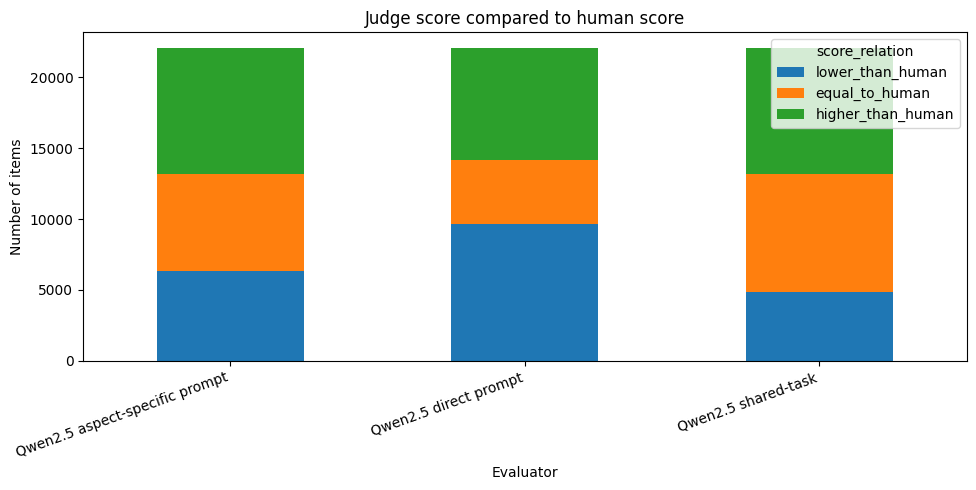

In [66]:
# Plot score-relation counts per evaluator
relation_overall.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("Judge score compared to human score")
plt.xlabel("Evaluator")
plt.ylabel("Number of items")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [67]:
# Score-relation counts per evaluator and aspect
relation_by_aspect = (
    df_score_long
    .groupby(["evaluator_label", "aspect", "score_relation"])
    .size()
    .reset_index(name="count")
)

display(relation_by_aspect.head())

,evaluator_label,aspect,score_relation,count
0,Qwen2.5 aspect-specific prompt,coherence,equal_to_human,2107
1,Qwen2.5 aspect-specific prompt,coherence,higher_than_human,2669
2,Qwen2.5 aspect-specific prompt,coherence,lower_than_human,2584
3,Qwen2.5 aspect-specific prompt,instruction_following,equal_to_human,3030
4,Qwen2.5 aspect-specific prompt,instruction_following,higher_than_human,3033


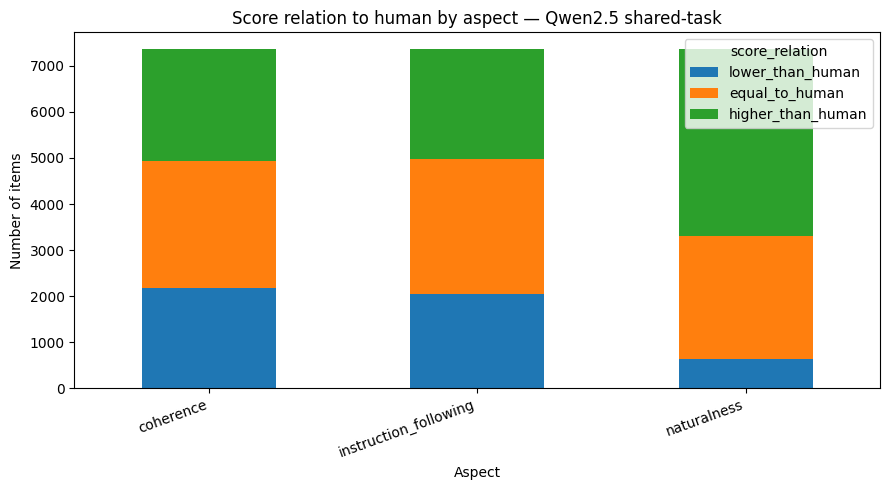

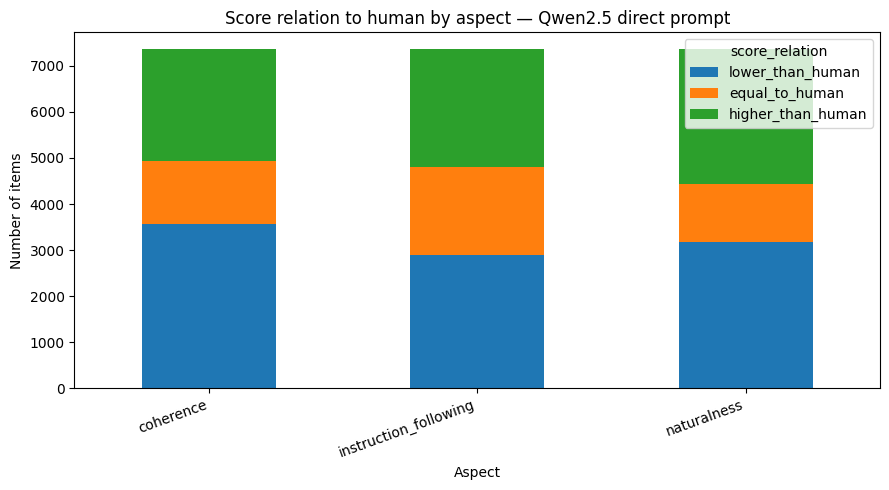

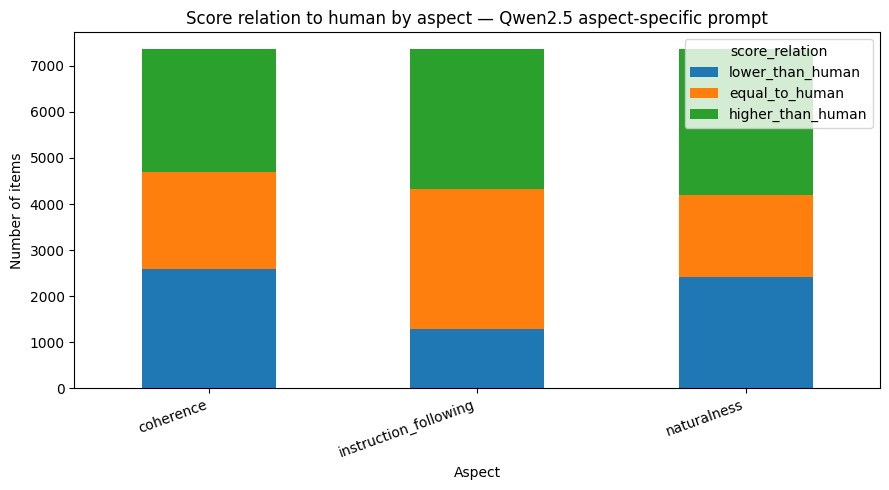

In [68]:
# Plot score-relation counts per evaluator, broken down by aspect
for evaluator in df_score_long["evaluator_label"].unique():
    sub = df_score_long[df_score_long["evaluator_label"] == evaluator]

    table = (
        sub
        .groupby(["aspect", "score_relation"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=relation_order, fill_value=0)
    )

    table.plot(
        kind="bar",
        stacked=True,
        figsize=(9, 5)
    )

    plt.title(f"Score relation to human by aspect — {evaluator}")
    plt.xlabel("Aspect")
    plt.ylabel("Number of items")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

In [69]:
# Define function to summarize judge-human score bias
def summarize_score_bias(df, group_cols):
    return (
        df
        .groupby(["evaluator_label"] + group_cols, as_index=False)
        .agg(
            n=("judge_score", "size"),
            human_mean=("human_score", "mean"),
            judge_mean=("judge_score", "mean"),
            mean_diff=("score_diff", "mean"),
            median_diff=("score_diff", "median"),
            std_diff=("score_diff", "std")
        )
    )

In [70]:
# Overall bias summary
bias_overall = summarize_score_bias(df_score_long, [])
display(bias_overall)

,evaluator_label,n,human_mean,judge_mean,mean_diff,median_diff,std_diff
0,Qwen2.5 aspect-specific prompt,22080,5.669248,6.070516,0.401268,0.0,1.655299
1,Qwen2.5 direct prompt,22080,5.669248,5.830208,0.160960,0.0,1.645408
2,Qwen2.5 shared-task,22080,5.669248,6.169882,0.500634,0.0,1.752600


In [71]:
# Bias summary by aspect
bias_by_aspect = summarize_score_bias(df_score_long, ["aspect"])
display(bias_by_aspect)

,evaluator_label,aspect,n,human_mean,judge_mean,mean_diff,median_diff,std_diff
0,Qwen2.5 aspect-specific prompt,coherence,7360,5.790217,6.098777,0.308560,0.0,1.539897
1,Qwen2.5 aspect-specific prompt,instruction_following,7360,5.869973,6.446332,0.576359,0.0,1.478619
2,Qwen2.5 aspect-specific prompt,naturalness,7360,5.347554,5.666440,0.318886,0.0,1.901880
3,Qwen2.5 direct prompt,coherence,7360,5.790217,5.867255,0.077038,0.0,1.529318
4,Qwen2.5 direct prompt,instruction_following,7360,5.869973,6.067120,0.197147,0.0,1.474287
5,Qwen2.5 direct prompt,naturalness,7360,5.347554,5.556250,0.208696,0.0,1.897332
6,Qwen2.5 shared-task,coherence,7360,5.790217,5.945924,0.155707,0.0,1.635636
7,Qwen2.5 shared-task,instruction_following,7360,5.869973,6.012500,0.142527,0.0,1.600529
8,Qwen2.5 shared-task,naturalness,7360,5.347554,6.551223,1.203668,1.0,1.799190


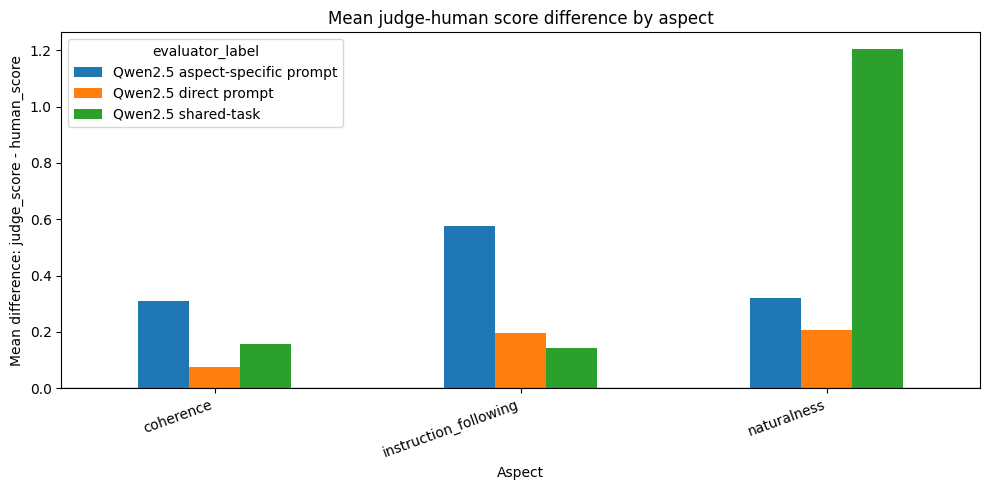

In [72]:
# Plot mean bias by aspect
pivot_aspect = bias_by_aspect.pivot(
    index="aspect",
    columns="evaluator_label",
    values="mean_diff"
)

pivot_aspect.plot(kind="bar", figsize=(10, 5))

plt.axhline(0, linewidth=1)
plt.title("Mean judge-human score difference by aspect")
plt.xlabel("Aspect")
plt.ylabel("Mean difference: judge_score - human_score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [73]:
# Define the target language for the English-bias check
target_language = "English (United States)"

In [74]:
# Define function to compare bias for a target group vs the rest
def compute_target_group_bias(
    bias_df,
    group_col,
    target_value,
    value_col="mean_diff"
):
    rows = []

    for evaluator, group in bias_df.groupby("evaluator_label"):
        target_mean = group.loc[
            group[group_col] == target_value,
            value_col
        ].mean()

        non_target_mean = group.loc[
            group[group_col] != target_value,
            value_col
        ].mean()

        rows.append({
            "evaluator_label": evaluator,
            "target_group": target_value,
            "target_mean_diff": target_mean,
            "non_target_mean_diff": non_target_mean,
            "bias_gap": target_mean - non_target_mean,
        })

    return pd.DataFrame(rows)

In [75]:
# Bias summary by language
bias_by_language = summarize_score_bias(df_score_long, ["language_locale"])
display(bias_by_language)

,evaluator_label,language_locale,n,human_mean,judge_mean,mean_diff,median_diff,std_diff
0,Qwen2.5 aspect-specific prompt,Bangla (Bangladesh),2208,3.756341,5.677083,1.920743,2.0,1.625735
1,Qwen2.5 aspect-specific prompt,Czech (Czechia),2208,5.624094,6.130435,0.506341,0.0,1.445884
2,Qwen2.5 aspect-specific prompt,Egyptian Arabic,2208,4.853261,5.811141,0.957880,0.0,2.005778
3,Qwen2.5 aspect-specific prompt,English (United States),2208,6.341938,6.181159,-0.160779,0.0,1.222046
4,Qwen2.5 aspect-specific prompt,German (Germany),2208,6.321105,6.254076,-0.067029,0.0,1.268288
5,Qwen2.5 aspect-specific prompt,Hindi (India),2208,5.805254,5.903533,0.098279,0.0,1.545515
6,Qwen2.5 aspect-specific prompt,Indonesian (Indonesia),2208,6.019022,6.184330,0.165308,0.0,1.482822
7,Qwen2.5 aspect-specific prompt,Japanese (Japan),2208,5.649457,6.197464,0.548007,0.0,1.762381
8,Qwen2.5 aspect-specific prompt,Russian (Russia),2208,6.266757,6.190217,-0.076540,0.0,1.339184
9,Qwen2.5 aspect-specific prompt,Simplified Chinese (China),2208,6.055254,6.175725,0.120471,0.0,1.556656


In [76]:
# Compare English bias vs non-English bias
english_bias = compute_target_group_bias(
    bias_by_language,
    group_col="language_locale",
    target_value=target_language
)

display(english_bias)

,evaluator_label,target_group,target_mean_diff,non_target_mean_diff,bias_gap
0,Qwen2.5 aspect-specific prompt,English (United States),-0.160779,0.463718,-0.624497
1,Qwen2.5 direct prompt,English (United States),-0.697011,0.256290,-0.953301
2,Qwen2.5 shared-task,English (United States),-0.024004,0.558927,-0.582931


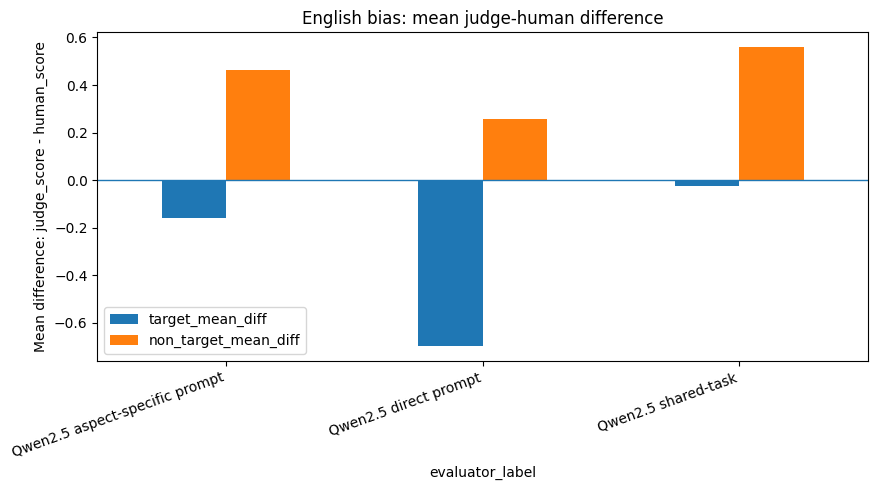

In [77]:
# Plot English vs non-English bias
english_bias.set_index("evaluator_label")[
    ["target_mean_diff", "non_target_mean_diff"]
].plot(kind="bar", figsize=(9, 5))

plt.axhline(0, linewidth=1)
plt.title("English bias: mean judge-human difference")
plt.ylabel("Mean difference: judge_score - human_score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

The English bias analysis does not indicate an English over-scoring tendency. Instead, all three Qwen2.5-based evaluators assign lower judge-human differences to English than to non-English data. The direct prompt shows the strongest imbalance, substantially under-scoring English while still over-scoring non-English responses. The aspect-specific prompt reduces this English under-scoring compared to the direct prompt, suggesting better calibration for English, although it still tends to over-score non-English responses. Overall, the observed bias is better described as non-English over-scoring relative to human judgments rather than English favoritism.

In [78]:
# Redefine key columns for the metric computations below
keys = ["doc_id", "system", "language_locale", "aspect"]
item_cols = ["doc_id", "language_locale", "aspect"]


In [79]:
# Define function to run a metric function for every evaluator/prompt variant
def run_metric_per_evaluator(metric_fn, **metric_kwargs):
    rows = []

    for score_col in score_cols:
        df_eval = (
            df_score_wide_common[
                keys + ["human_score", score_col]
            ]
            .dropna(subset=["human_score", score_col])
            .rename(columns={score_col: "judge_score"})
            .copy()
        )

        result = metric_fn(df_eval, **metric_kwargs)
        result["evaluator"] = score_col
        result["evaluator_label"] = evaluator_name_map[score_col]
        rows.append(result)

    return pd.concat(rows, ignore_index=True)


In [80]:
# Overall pairwise accuracy per evaluator
pairwise_overall = run_metric_per_evaluator(compute_system_pairwise_accuracy, group_cols=[])
display(pairwise_overall)


,pairwise_accuracy,correct_pairs,n_pairs,human_ties_ignored,n_systems,evaluator,evaluator_label
0,0.700000,84,120,0,16,shared_task_qwen25,Qwen2.5 shared-task
1,0.708333,85,120,0,16,direct_prompt,Qwen2.5 direct prompt
2,0.733333,88,120,0,16,aspect_specific_prompt,Qwen2.5 aspect-specific prompt


In [81]:
# Pairwise accuracy per evaluator, by aspect
pairwise_by_aspect = run_metric_per_evaluator(compute_system_pairwise_accuracy, group_cols=["aspect"])
display(pairwise_by_aspect)


,aspect,pairwise_accuracy,correct_pairs,n_pairs,human_ties_ignored,n_systems,evaluator,evaluator_label
0,coherence,0.716667,86,120,0,16,shared_task_qwen25,Qwen2.5 shared-task
1,instruction_following,0.775000,93,120,0,16,shared_task_qwen25,Qwen2.5 shared-task
2,naturalness,0.680672,81,119,1,16,shared_task_qwen25,Qwen2.5 shared-task
3,coherence,0.683333,82,120,0,16,direct_prompt,Qwen2.5 direct prompt
4,instruction_following,0.733333,88,120,0,16,direct_prompt,Qwen2.5 direct prompt
5,naturalness,0.714286,85,119,1,16,direct_prompt,Qwen2.5 direct prompt
6,coherence,0.683333,82,120,0,16,aspect_specific_prompt,Qwen2.5 aspect-specific prompt
7,instruction_following,0.766667,92,120,0,16,aspect_specific_prompt,Qwen2.5 aspect-specific prompt
8,naturalness,0.756303,90,119,1,16,aspect_specific_prompt,Qwen2.5 aspect-specific prompt


In [82]:
# Pairwise accuracy per evaluator, by language
pairwise_by_language = run_metric_per_evaluator(compute_system_pairwise_accuracy, group_cols=["language_locale"])
display(pairwise_by_language)


,language_locale,pairwise_accuracy,correct_pairs,n_pairs,human_ties_ignored,n_systems,evaluator,evaluator_label
0,Bangla (Bangladesh),0.840336,100,119,1,16,shared_task_qwen25,Qwen2.5 shared-task
1,Czech (Czechia),0.689076,82,119,1,16,shared_task_qwen25,Qwen2.5 shared-task
2,Egyptian Arabic,0.600000,72,120,0,16,shared_task_qwen25,Qwen2.5 shared-task
3,English (United States),0.560345,65,116,4,16,shared_task_qwen25,Qwen2.5 shared-task
4,German (Germany),0.655462,78,119,1,16,shared_task_qwen25,Qwen2.5 shared-task
5,Hindi (India),0.766667,92,120,0,16,shared_task_qwen25,Qwen2.5 shared-task
6,Indonesian (Indonesia),0.605042,72,119,1,16,shared_task_qwen25,Qwen2.5 shared-task
7,Japanese (Japan),0.672269,80,119,1,16,shared_task_qwen25,Qwen2.5 shared-task
8,Russian (Russia),0.666667,80,120,0,16,shared_task_qwen25,Qwen2.5 shared-task
9,Simplified Chinese (China),0.731092,87,119,1,16,shared_task_qwen25,Qwen2.5 shared-task


In [83]:
# Item-level acc_eq components per evaluator
acceq_item_df = run_metric_per_evaluator(compute_acceq_by_item, item_cols=item_cols)

print(acceq_item_df.shape)
display(acceq_item_df.head())


(4140, 12)


,doc_id,language_locale,aspect,acceq,C,D,T_h,T_m,T_hm,n_pairs,evaluator,evaluator_label
0,0a3da1ceeb83f664b813bb28f001d766,Bangla (Bangladesh),coherence,0.475000,15,0,0,63,42,120,shared_task_qwen25,Qwen2.5 shared-task
1,0a3da1ceeb83f664b813bb28f001d766,Bangla (Bangladesh),instruction_following,0.450000,23,0,6,60,31,120,shared_task_qwen25,Qwen2.5 shared-task
2,0a3da1ceeb83f664b813bb28f001d766,Bangla (Bangladesh),naturalness,0.541667,35,6,18,31,30,120,shared_task_qwen25,Qwen2.5 shared-task
3,0a3da1ceeb83f664b813bb28f001d766,Czech (Czechia),coherence,0.425000,29,10,9,50,22,120,shared_task_qwen25,Qwen2.5 shared-task
4,0a3da1ceeb83f664b813bb28f001d766,Czech (Czechia),instruction_following,0.275000,27,26,12,49,6,120,shared_task_qwen25,Qwen2.5 shared-task


In [84]:
# Overall acc_eq per evaluator
acceq_overall = summarize_acceq_from_items(acceq_item_df, group_cols=["evaluator_label"])
display(acceq_overall)


,evaluator_label,acceq,n_items,avg_pairs,C,D,T_h,T_m,T_hm,n_pairs
0,Qwen2.5 aspect-specific prompt,0.477258,1380,120.0,29550,12768,33068,40730,49484,165600
1,Qwen2.5 direct prompt,0.478436,1380,120.0,21201,9190,24524,52657,58028,165600
2,Qwen2.5 shared-task,0.476008,1380,120.0,21477,9541,25202,52030,57350,165600


In [85]:
# acc_eq per evaluator, by aspect
acceq_by_aspect = summarize_acceq_from_items(acceq_item_df, group_cols=["evaluator_label", "aspect"])
display(acceq_by_aspect)


,evaluator_label,aspect,acceq,n_items,avg_pairs,C,D,T_h,T_m,T_hm,n_pairs
0,Qwen2.5 aspect-specific prompt,coherence,0.480290,460,120.0,9265,3697,11328,13663,17247,55200
1,Qwen2.5 aspect-specific prompt,instruction_following,0.515888,460,120.0,8206,3290,9604,13829,20271,55200
2,Qwen2.5 aspect-specific prompt,naturalness,0.435598,460,120.0,12079,5781,12136,13238,11966,55200
3,Qwen2.5 direct prompt,coherence,0.513804,460,120.0,6143,2135,6356,18347,22219,55200
4,Qwen2.5 direct prompt,instruction_following,0.487409,460,120.0,6749,3157,9719,15419,20156,55200
5,Qwen2.5 direct prompt,naturalness,0.434094,460,120.0,8309,3898,8449,18891,15653,55200
6,Qwen2.5 shared-task,coherence,0.479275,460,120.0,6684,3289,8803,16652,19772,55200
7,Qwen2.5 shared-task,instruction_following,0.485670,460,120.0,7742,3430,10808,14153,19067,55200
8,Qwen2.5 shared-task,naturalness,0.463080,460,120.0,7051,2822,5591,21225,18511,55200


In [86]:
# acc_eq per evaluator, by language
acceq_by_language = summarize_acceq_from_items(acceq_item_df, group_cols=["evaluator_label", "language_locale"])
display(acceq_by_language)


,evaluator_label,language_locale,acceq,n_items,avg_pairs,C,D,T_h,T_m,T_hm,n_pairs
0,Qwen2.5 aspect-specific prompt,Bangla (Bangladesh),0.456643,138,120.0,5050,1789,2686,4523,2512,16560
1,Qwen2.5 aspect-specific prompt,Czech (Czechia),0.404287,138,120.0,3360,1712,2160,5993,3335,16560
2,Qwen2.5 aspect-specific prompt,Egyptian Arabic,0.515882,138,120.0,3865,1068,3588,3361,4678,16560
3,Qwen2.5 aspect-specific prompt,English (United States),0.530374,138,120.0,1455,796,3899,3082,7328,16560
4,Qwen2.5 aspect-specific prompt,German (Germany),0.473188,138,120.0,1832,1126,3276,4322,6004,16560
5,Qwen2.5 aspect-specific prompt,Hindi (India),0.515700,138,120.0,3405,971,3900,3149,5135,16560
6,Qwen2.5 aspect-specific prompt,Indonesian (Indonesia),0.436836,138,120.0,2821,1484,2828,5014,4413,16560
7,Qwen2.5 aspect-specific prompt,Japanese (Japan),0.448430,138,120.0,3206,1468,2803,4863,4220,16560
8,Qwen2.5 aspect-specific prompt,Russian (Russia),0.503382,138,120.0,2575,1294,3257,3673,5761,16560
9,Qwen2.5 aspect-specific prompt,Simplified Chinese (China),0.487862,138,120.0,1981,1060,4671,2750,6098,16560


In [87]:
# Merge overall pairwise accuracy and acc_eq into one summary table
metrics_overall = pairwise_overall.merge(
    acceq_overall[
        ["evaluator_label", "C", "D", "T_h", "T_m", "T_hm", "n_pairs", "acceq"]
    ],
    on="evaluator_label",
    suffixes=("_pairwise", "_acceq")
)

display(metrics_overall)

,pairwise_accuracy,correct_pairs,n_pairs_pairwise,human_ties_ignored,n_systems,evaluator,evaluator_label,C,D,T_h,T_m,T_hm,n_pairs_acceq,acceq
0,0.700000,84,120,0,16,shared_task_qwen25,Qwen2.5 shared-task,21477,9541,25202,52030,57350,165600,0.476008
1,0.708333,85,120,0,16,direct_prompt,Qwen2.5 direct prompt,21201,9190,24524,52657,58028,165600,0.478436
2,0.733333,88,120,0,16,aspect_specific_prompt,Qwen2.5 aspect-specific prompt,29550,12768,33068,40730,49484,165600,0.477258


With the global pairwise-accuracy formula (aggregate scores to the system level first, then compare every system pair against the human ranking), both prompt-engineered variants outperform the shared-task Qwen2.5 judge overall: aspect-specific prompt reaches an overall pairwise accuracy of **0.733**, direct prompt **0.708**, versus **0.700** for the shared-task judge. This gain is not uniform across aspects, though -- on coherence the shared-task judge is actually the best of the three (0.717 vs 0.683 for both prompt variants), while the prompt-engineered variants pull ahead mainly on naturalness (aspect-specific 0.756, direct 0.714, vs 0.681 shared-task) and, for aspect-specific prompt, instruction following too (0.767 vs 0.775 shared-task, direct 0.733).

ACCEQ (item-level, summed C/T_hm over total pairs) is close across all three evaluators -- shared-task **0.476**, aspect-specific **0.477**, direct **0.478** -- essentially indistinguishable, mainly reflecting similar tie-agreement rates rather than a meaningfully better ranking ability for either prompt variant.

Overall, the aspect-specific prompt gives the clearest system-ranking improvement over the shared-task baseline (driven by naturalness), while tie calibration (acceq) stays roughly the same across all three evaluators.

In [88]:
# Merge pairwise accuracy and acc_eq by aspect
metrics_by_aspect = pairwise_by_aspect.merge(
    acceq_by_aspect[
        ["evaluator_label", "aspect", "C", "D", "T_h", "T_m", "T_hm", "n_pairs", "acceq"]
    ],
    on=["evaluator_label", "aspect"],
    suffixes=("_pairwise", "_acceq")
)

display(metrics_by_aspect)

,aspect,pairwise_accuracy,correct_pairs,n_pairs_pairwise,human_ties_ignored,n_systems,evaluator,evaluator_label,C,D,T_h,T_m,T_hm,n_pairs_acceq,acceq
0,coherence,0.716667,86,120,0,16,shared_task_qwen25,Qwen2.5 shared-task,6684,3289,8803,16652,19772,55200,0.479275
1,instruction_following,0.775000,93,120,0,16,shared_task_qwen25,Qwen2.5 shared-task,7742,3430,10808,14153,19067,55200,0.485670
2,naturalness,0.680672,81,119,1,16,shared_task_qwen25,Qwen2.5 shared-task,7051,2822,5591,21225,18511,55200,0.463080
3,coherence,0.683333,82,120,0,16,direct_prompt,Qwen2.5 direct prompt,6143,2135,6356,18347,22219,55200,0.513804
4,instruction_following,0.733333,88,120,0,16,direct_prompt,Qwen2.5 direct prompt,6749,3157,9719,15419,20156,55200,0.487409
5,naturalness,0.714286,85,119,1,16,direct_prompt,Qwen2.5 direct prompt,8309,3898,8449,18891,15653,55200,0.434094
6,coherence,0.683333,82,120,0,16,aspect_specific_prompt,Qwen2.5 aspect-specific prompt,9265,3697,11328,13663,17247,55200,0.480290
7,instruction_following,0.766667,92,120,0,16,aspect_specific_prompt,Qwen2.5 aspect-specific prompt,8206,3290,9604,13829,20271,55200,0.515888
8,naturalness,0.756303,90,119,1,16,aspect_specific_prompt,Qwen2.5 aspect-specific prompt,12079,5781,12136,13238,11966,55200,0.435598


In [89]:
# Merge pairwise accuracy and acc_eq by language
metrics_by_language = pairwise_by_language.merge(
    acceq_by_language[
        ["evaluator_label", "language_locale", "C", "D", "T_h", "T_m", "T_hm", "n_pairs", "acceq"]
    ],
    on=["evaluator_label", "language_locale"],
    suffixes=("_pairwise", "_acceq")
)

display(metrics_by_language)

,language_locale,pairwise_accuracy,correct_pairs,n_pairs_pairwise,human_ties_ignored,n_systems,evaluator,evaluator_label,C,D,T_h,T_m,T_hm,n_pairs_acceq,acceq
0,Bangla (Bangladesh),0.840336,100,119,1,16,shared_task_qwen25,Qwen2.5 shared-task,3852,1113,1832,6397,3366,16560,0.435870
1,Czech (Czechia),0.689076,82,119,1,16,shared_task_qwen25,Qwen2.5 shared-task,2500,1475,1755,7090,3740,16560,0.376812
2,Egyptian Arabic,0.600000,72,120,0,16,shared_task_qwen25,Qwen2.5 shared-task,2747,870,3099,4677,5167,16560,0.477899
3,English (United States),0.560345,65,116,4,16,shared_task_qwen25,Qwen2.5 shared-task,1015,897,3375,3421,7852,16560,0.535447
4,German (Germany),0.655462,78,119,1,16,shared_task_qwen25,Qwen2.5 shared-task,1369,913,2897,4998,6383,16560,0.468116
5,Hindi (India),0.766667,92,120,0,16,shared_task_qwen25,Qwen2.5 shared-task,2543,671,3024,4311,6011,16560,0.516546
6,Indonesian (Indonesia),0.605042,72,119,1,16,shared_task_qwen25,Qwen2.5 shared-task,2061,1151,2246,6107,4995,16560,0.426087
7,Japanese (Japan),0.672269,80,119,1,16,shared_task_qwen25,Qwen2.5 shared-task,2467,993,1869,6077,5154,16560,0.460205
8,Russian (Russia),0.666667,80,120,0,16,shared_task_qwen25,Qwen2.5 shared-task,1710,815,2528,5017,6490,16560,0.495169
9,Simplified Chinese (China),0.731092,87,119,1,16,shared_task_qwen25,Qwen2.5 shared-task,1213,643,2577,3935,8192,16560,0.567935


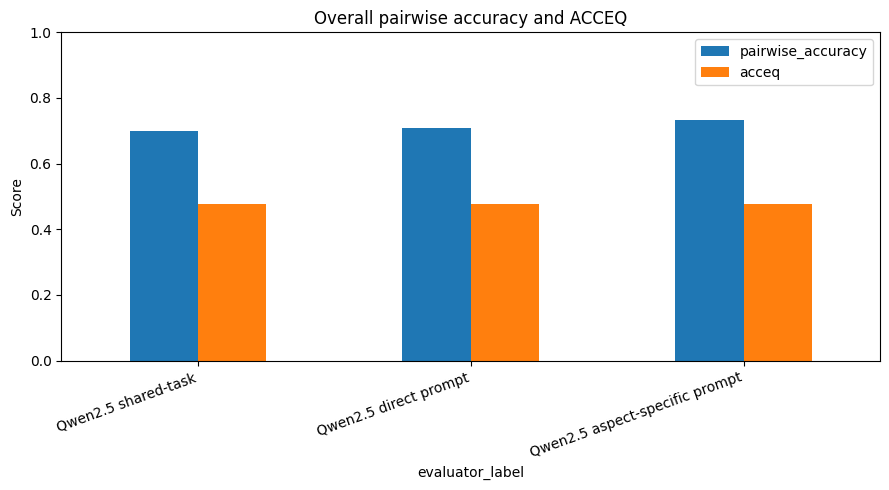

In [90]:
# Plot overall pairwise accuracy and acc_eq per evaluator
overall_plot = metrics_overall.set_index("evaluator_label")[
    ["pairwise_accuracy", "acceq"]
]

overall_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Overall pairwise accuracy and ACCEQ")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

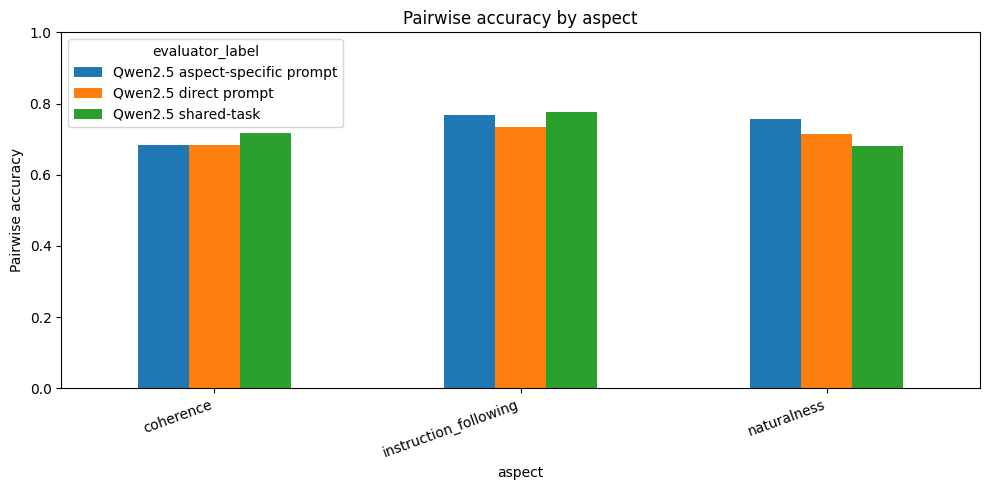

In [91]:
# Plot pairwise accuracy by aspect per evaluator
pivot_aspect_pairwise = metrics_by_aspect.pivot(
    index="aspect",
    columns="evaluator_label",
    values="pairwise_accuracy"
)

pivot_aspect_pairwise.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Pairwise accuracy by aspect")
plt.ylabel("Pairwise accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

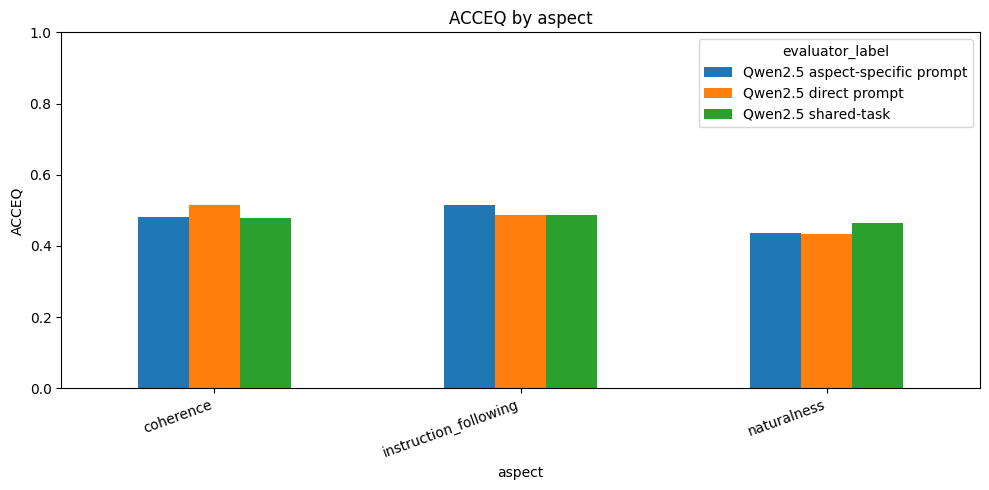

In [92]:
# Plot acc_eq by aspect per evaluator
pivot_aspect_acceq = metrics_by_aspect.pivot(
    index="aspect",
    columns="evaluator_label",
    values="acceq"
)

pivot_aspect_acceq.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("ACCEQ by aspect")
plt.ylabel("ACCEQ")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

##Week 8:test on large model




In [93]:
# Set up paths and key columns for the Week 8 DeepSeek evaluation
from pathlib import Path
import json
import numpy as np
import pandas as pd
from itertools import combinations

# /content/... is the Colab layout; fall back to cwd-relative paths so this
# also runs in a plain local Jupyter session (see cell 7 for the same idea).
PROJECT_ROOT = Path("/content/llm-as-a-judge-praktikum")
WMT_ROOT = Path("/content/wmt-mist")
if not PROJECT_ROOT.exists():
    PROJECT_ROOT = Path("llm-as-a-judge-praktikum")
if not WMT_ROOT.exists():
    WMT_ROOT = Path("wmt-mist")
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

ASPECTS = ["coherence", "naturalness", "instruction_following"]

KEYS_WITH_SEGMENT = [
    "doc_id",
    "segment_id",
    "system",
    "language_locale",
    "aspect",
]

KEYS_NO_SEGMENT = [
    "doc_id",
    "system",
    "language_locale",
    "aspect",
]

In [94]:
# Rebuild the human rating long-format table with segment_id for the DeepSeek comparison
import re
import urllib.request

PROJECT_HUMAN_PATH = PROJECT_ROOT / "data/humeval/oeg.json"


def _is_lfs_pointer(path):
    if not path.exists():
        return True
    with open(path, "r", encoding="utf-8", errors="ignore") as fh:
        return fh.read(200).startswith("version https://git-lfs")


# Prefer the verified copy cached in this project's own data/ folder over a
# fresh wmt-mist clone (see cell 7 for why: a plain clone can come back
# incomplete and silently produce wrong downstream numbers).
if PROJECT_HUMAN_PATH.exists() and not _is_lfs_pointer(PROJECT_HUMAN_PATH):
    human_path = PROJECT_HUMAN_PATH
else:
    human_path = WMT_ROOT / "data/humeval/oeg.json"

MIST_MIRROR_URL = "https://data.statmt.org/wmt25/general-mt/blindset_mist_2025.json"
PROJECT_MIST_PATH = PROJECT_ROOT / "data/mist_25.json"


def is_lfs_pointer(path):
    if not path.exists():
        return True
    with open(path, "r", encoding="utf-8", errors="ignore") as fh:
        return fh.read(200).startswith("version https://git-lfs")


def resolve_mist_path():
    for candidate in [PROJECT_MIST_PATH, WMT_ROOT / "data/mist_25.json"]:
        if candidate.exists() and not is_lfs_pointer(candidate):
            return candidate
    target = PROJECT_MIST_PATH
    target.parent.mkdir(parents=True, exist_ok=True)
    print(f"mist_25.json not usable locally, downloading from {MIST_MIRROR_URL} ...")
    urllib.request.urlretrieve(MIST_MIRROR_URL, target)
    return target


mist_path = resolve_mist_path()
print(f"Using mist_25.json from: {mist_path}")

with open(human_path, "r", encoding="utf-8") as f:
    human_data = json.load(f)

with open(mist_path, "r", encoding="utf-8") as f:
    mist_data = json.load(f)

df_human = pd.DataFrame(human_data)
df_mist = pd.DataFrame(mist_data)

df_mist_oeg = df_mist[
    df_mist["taskid"].str.startswith("open_ended_generation", na=False)
].copy()

prefix = "open_ended_generation_"
df_mist_oeg["doc_segment"] = df_mist_oeg["taskid"].str.replace(
    prefix, "", regex=False
)

df_mist_oeg["doc_id"] = df_mist_oeg["doc_segment"].str.rsplit("_", n=1).str[0]
df_mist_oeg["segment_id"] = df_mist_oeg["doc_segment"].str.rsplit("_", n=1).str[1]


def normalize_prompt(text):
    """Collapse '<br>' HTML line breaks so they line up with the plain-text
    prompts in mist_25.json (see cell 25 for the same fix)."""
    text = re.sub(r"<br\s*/?>", "\n", text, flags=re.IGNORECASE)
    return text.strip()


df_human["prompt_key"] = df_human["prompt"].map(normalize_prompt)
df_mist_oeg["prompt_key"] = df_mist_oeg["prompt"].map(normalize_prompt)

df_segment_map = df_mist_oeg[
    ["doc_id", "segment_id", "prompt_key"]
].drop_duplicates()

df_human_with_segment = df_human.merge(
    df_segment_map,
    on=["doc_id", "prompt_key"],
    how="left",
)

n_unmatched = df_human_with_segment["segment_id"].isna().sum()
print(f"Rows without a segment_id match: {n_unmatched} / {len(df_human_with_segment)}")

df_human_clean = df_human_with_segment.dropna(subset=["segment_id"]).copy()
df_human_clean["segment_id"] = df_human_clean["segment_id"].astype(int).astype(str)

df_human_long_deepseek = df_human_clean.melt(
    id_vars=[
        "doc_id",
        "segment_id",
        "system",
        "language",
        "language_locale",
        "prompt",
        "response",
    ],
    value_vars=ASPECTS,
    var_name="aspect",
    value_name="human_score",
)

human_base = (
    df_human_long_deepseek[
        KEYS_WITH_SEGMENT + ["human_score"]
    ]
    .drop_duplicates(KEYS_WITH_SEGMENT)
    .copy()
)

display(human_base.head())

Using mist_25.json from: llm-as-a-judge-praktikum/data/mist_25.json


Rows without a segment_id match: 0 / 7360


,doc_id,segment_id,system,language_locale,aspect,human_score
0,104373856e995a074579797ebe34fcb2,293,Gemma-3-12B,Egyptian Arabic,coherence,7.0
1,fb2c387e7e5272a43305940219116463,239,Gemma-3-12B,Egyptian Arabic,coherence,6.0
2,e91353a8c4dde03994b2cbfb5521172e,298,Mistral-Medium,Egyptian Arabic,coherence,5.0
3,170d490a7ae53347e8fe3eabe4e28001,288,Qwen3-235B,Egyptian Arabic,coherence,7.0
4,14e076d13751e87d8c09f7f13125e755,241,CommandR7B,Egyptian Arabic,coherence,7.0


In [95]:
# Define function to load and clean an OpenRouter prompt-score CSV, then load the DeepSeek direct/aspect prompt scores
def load_prompt_scores(path, score_col_name):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()

    required = KEYS_NO_SEGMENT + ["judge_score"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{path.name} is missing columns: {missing}")

    df = df[required].copy()
    df["aspect"] = df["aspect"].astype(str).str.strip()
    df["judge_score"] = pd.to_numeric(df["judge_score"], errors="coerce")

    df = df[
        df["aspect"].isin(ASPECTS)
    ].dropna(subset=KEYS_NO_SEGMENT + ["judge_score"])

    # If duplicate keys exist for any reason, average them so merges don't blow up the row count.
    df = (
        df.groupby(KEYS_NO_SEGMENT, as_index=False)["judge_score"]
        .mean()
        .rename(columns={"judge_score": score_col_name})
    )

    return df


direct_deepseek = load_prompt_scores(
    RESULTS_DIR / "openrouter_direct_prompt_full_deepseek.csv",
    "direct_prompt",
)

aspect_deepseek = load_prompt_scores(
    RESULTS_DIR / "openrouter_aspect_specific_prompt_full_deepseek.csv",
    "aspect_specific_prompt",
)

display(direct_deepseek.head())
display(aspect_deepseek.head())


,doc_id,system,language_locale,aspect,direct_prompt
0,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),coherence,4.0
1,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),instruction_following,3.0
2,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),naturalness,4.0
3,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Czech (Czechia),coherence,6.0
4,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Czech (Czechia),instruction_following,6.0


,doc_id,system,language_locale,aspect,aspect_specific_prompt
0,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),coherence,3.0
1,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),instruction_following,5.0
2,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),naturalness,3.0
3,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Czech (Czechia),coherence,6.0
4,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Czech (Czechia),instruction_following,7.0


In [96]:
# Define function to fetch the shared-task DeepSeek judge scores
def get_shared_task_deepseek():
    if "df_deepseek_v3_merged" in globals():
        df = df_deepseek_v3_merged.copy()
    elif "all_merged" in globals():
        df = all_merged[
            all_merged["judge_model"]
            .astype(str)
            .str.contains("deepseek", case=False, na=False)
        ].copy()
    else:
        raise NameError(
            "Please run the earlier shared-task merge cells first, "
            "so that df_deepseek_v3_merged or all_merged exists."
        )

    required = KEYS_WITH_SEGMENT + ["judge_score"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Shared-task DeepSeek table is missing columns: {missing}")

    df = df[required].copy()
    df["segment_id"] = df["segment_id"].astype(int).astype(str)
    df["aspect"] = df["aspect"].astype(str).str.strip()
    df["judge_score"] = pd.to_numeric(df["judge_score"], errors="coerce")

    df = df[
        df["aspect"].isin(ASPECTS)
    ].dropna(subset=KEYS_WITH_SEGMENT + ["judge_score"])

    df = (
        df.groupby(KEYS_WITH_SEGMENT, as_index=False)["judge_score"]
        .mean()
        .rename(columns={"judge_score": "shared_task_deepseek"})
    )

    return df


shared_deepseek = get_shared_task_deepseek()

display(shared_deepseek.head())


,doc_id,segment_id,system,language_locale,aspect,shared_task_deepseek
0,0a3da1ceeb83f664b813bb28f001d766,1170,AyaExpanse-32B,Indonesian (Indonesia),coherence,7.0
1,0a3da1ceeb83f664b813bb28f001d766,1170,AyaExpanse-32B,Indonesian (Indonesia),instruction_following,7.0
2,0a3da1ceeb83f664b813bb28f001d766,1170,AyaExpanse-32B,Indonesian (Indonesia),naturalness,7.0
3,0a3da1ceeb83f664b813bb28f001d766,1170,AyaExpanse-8B,Indonesian (Indonesia),coherence,7.0
4,0a3da1ceeb83f664b813bb28f001d766,1170,AyaExpanse-8B,Indonesian (Indonesia),instruction_following,7.0


In [97]:
# Merge human, prompt-variant, and shared-task DeepSeek scores into one wide table
deepseek_score_wide = (
    human_base
    .merge(
        direct_deepseek,
        on=KEYS_NO_SEGMENT,
        how="left",
    )
    .merge(
        aspect_deepseek,
        on=KEYS_NO_SEGMENT,
        how="left",
    )
    .merge(
        shared_deepseek,
        on=KEYS_WITH_SEGMENT,
        how="left",
    )
)

score_cols = [
    "shared_task_deepseek",
    "direct_prompt",
    "aspect_specific_prompt",
]

deepseek_score_wide_common = deepseek_score_wide.dropna(
    subset=["human_score"] + score_cols
).copy()

display(deepseek_score_wide_common.head())


,doc_id,segment_id,system,language_locale,aspect,human_score,direct_prompt,aspect_specific_prompt,shared_task_deepseek
0,104373856e995a074579797ebe34fcb2,293,Gemma-3-12B,Egyptian Arabic,coherence,7.0,6.0,6.0,7.0
1,fb2c387e7e5272a43305940219116463,239,Gemma-3-12B,Egyptian Arabic,coherence,6.0,6.0,6.0,7.0
2,e91353a8c4dde03994b2cbfb5521172e,298,Mistral-Medium,Egyptian Arabic,coherence,5.0,6.0,6.0,7.0
3,170d490a7ae53347e8fe3eabe4e28001,288,Qwen3-235B,Egyptian Arabic,coherence,7.0,6.0,6.0,7.0
4,14e076d13751e87d8c09f7f13125e755,241,CommandR7B,Egyptian Arabic,coherence,7.0,6.0,6.0,6.0


In [98]:
# Convert the wide DeepSeek score table to long format
evaluator_name_map = {
    "shared_task_deepseek": "DeepSeek shared-task",
    "direct_prompt": "DeepSeek direct prompt",
    "aspect_specific_prompt": "DeepSeek aspect-specific prompt",
}

deepseek_score_long = deepseek_score_wide_common.melt(
    id_vars=KEYS_WITH_SEGMENT + ["human_score"],
    value_vars=score_cols,
    var_name="evaluator",
    value_name="judge_score",
)

deepseek_score_long["evaluator_label"] = deepseek_score_long["evaluator"].map(
    evaluator_name_map
)

deepseek_score_long["score_diff"] = (
    deepseek_score_long["judge_score"] - deepseek_score_long["human_score"]
)

display(deepseek_score_long.head())


,doc_id,segment_id,system,language_locale,aspect,human_score,evaluator,judge_score,evaluator_label,score_diff
0,104373856e995a074579797ebe34fcb2,293,Gemma-3-12B,Egyptian Arabic,coherence,7.0,shared_task_deepseek,7.0,DeepSeek shared-task,0.0
1,fb2c387e7e5272a43305940219116463,239,Gemma-3-12B,Egyptian Arabic,coherence,6.0,shared_task_deepseek,7.0,DeepSeek shared-task,1.0
2,e91353a8c4dde03994b2cbfb5521172e,298,Mistral-Medium,Egyptian Arabic,coherence,5.0,shared_task_deepseek,7.0,DeepSeek shared-task,2.0
3,170d490a7ae53347e8fe3eabe4e28001,288,Qwen3-235B,Egyptian Arabic,coherence,7.0,shared_task_deepseek,7.0,DeepSeek shared-task,0.0
4,14e076d13751e87d8c09f7f13125e755,241,CommandR7B,Egyptian Arabic,coherence,7.0,shared_task_deepseek,6.0,DeepSeek shared-task,-1.0


In [99]:
# Reuse get_relation, compute_system_pairwise_accuracy, compute_acceq_by_item,
# and summarize_acceq_from_items defined earlier (Week 3, cells above) -- they are
# identical formulas, so we don't redefine them here.


In [100]:
# Define run_metric_per_evaluator for the DeepSeek wide table (separate from the Week 7 version in cell 152: it reads deepseek_score_wide_common/KEYS_WITH_SEGMENT instead of df_score_wide_common/keys), then compute item-level acc_eq
item_cols = ["doc_id", "segment_id", "language_locale", "aspect"]


def run_metric_per_evaluator(metric_fn, **metric_kwargs):
    rows = []

    for score_col in score_cols:
        df_eval = (
            deepseek_score_wide_common[
                KEYS_WITH_SEGMENT + ["human_score", score_col]
            ]
            .rename(columns={score_col: "judge_score"})
            .copy()
        )

        result = metric_fn(df_eval, **metric_kwargs)
        result["evaluator"] = score_col
        result["evaluator_label"] = evaluator_name_map[score_col]
        rows.append(result)

    return pd.concat(rows, ignore_index=True)


deepseek_acceq_items = run_metric_per_evaluator(compute_acceq_by_item, item_cols=item_cols)

display(deepseek_acceq_items.head())


,doc_id,segment_id,language_locale,aspect,acceq,C,D,T_h,T_m,T_hm,n_pairs,evaluator,evaluator_label
0,0a3da1ceeb83f664b813bb28f001d766,1170,Indonesian (Indonesia),coherence,0.225000,0,0,0,93,27,120,shared_task_deepseek,DeepSeek shared-task
1,0a3da1ceeb83f664b813bb28f001d766,1170,Indonesian (Indonesia),instruction_following,1.000000,0,0,0,0,120,120,shared_task_deepseek,DeepSeek shared-task
2,0a3da1ceeb83f664b813bb28f001d766,1170,Indonesian (Indonesia),naturalness,0.508333,0,0,0,59,61,120,shared_task_deepseek,DeepSeek shared-task
3,0a3da1ceeb83f664b813bb28f001d766,1370,Japanese (Japan),coherence,0.758333,13,1,1,27,78,120,shared_task_deepseek,DeepSeek shared-task
4,0a3da1ceeb83f664b813bb28f001d766,1370,Japanese (Japan),instruction_following,0.316667,0,6,9,67,38,120,shared_task_deepseek,DeepSeek shared-task


In [101]:
# Merge overall pairwise accuracy and acc_eq for the DeepSeek evaluators
deepseek_pairwise_overall = run_metric_per_evaluator(compute_system_pairwise_accuracy, group_cols=[])
deepseek_acceq_overall = summarize_acceq_from_items(deepseek_acceq_items, group_cols=["evaluator_label"])

deepseek_metrics_summary = (
    deepseek_pairwise_overall
    .merge(
        deepseek_acceq_overall[
            ["evaluator_label", "C", "D", "T_h", "T_m", "T_hm", "n_pairs", "acceq"]
        ],
        on="evaluator_label",
        suffixes=("_pairwise", "_acceq"),
    )
    .sort_values("acceq", ascending=False)
    .reset_index(drop=True)
)

display(deepseek_metrics_summary)


,pairwise_accuracy,correct_pairs,n_pairs_pairwise,human_ties_ignored,n_systems,evaluator,evaluator_label,C,D,T_h,T_m,T_hm,n_pairs_acceq,acceq
0,0.850000,102,120,0,16,shared_task_deepseek,DeepSeek shared-task,22024,5311,15394,55356,66780,164865,0.538851
1,0.900000,108,120,0,16,aspect_specific_prompt,DeepSeek aspect-specific prompt,30937,9290,28182,42464,53992,164865,0.514995
2,0.858333,103,120,0,16,direct_prompt,DeepSeek direct prompt,27243,7856,25118,47592,57056,164865,0.511182


In [102]:
# Pairwise accuracy for DeepSeek evaluators, by aspect
deepseek_pairwise_by_aspect = run_metric_per_evaluator(compute_system_pairwise_accuracy, group_cols=["aspect"])
display(deepseek_pairwise_by_aspect)


,aspect,pairwise_accuracy,correct_pairs,n_pairs,human_ties_ignored,n_systems,evaluator,evaluator_label
0,coherence,0.833333,100,120,0,16,shared_task_deepseek,DeepSeek shared-task
1,instruction_following,0.908333,109,120,0,16,shared_task_deepseek,DeepSeek shared-task
2,naturalness,0.791667,95,120,0,16,shared_task_deepseek,DeepSeek shared-task
3,coherence,0.841667,101,120,0,16,direct_prompt,DeepSeek direct prompt
4,instruction_following,0.891667,107,120,0,16,direct_prompt,DeepSeek direct prompt
5,naturalness,0.850000,102,120,0,16,direct_prompt,DeepSeek direct prompt
6,coherence,0.916667,110,120,0,16,aspect_specific_prompt,DeepSeek aspect-specific prompt
7,instruction_following,0.875000,105,120,0,16,aspect_specific_prompt,DeepSeek aspect-specific prompt
8,naturalness,0.816667,98,120,0,16,aspect_specific_prompt,DeepSeek aspect-specific prompt


In [103]:
# acc_eq for DeepSeek evaluators, by aspect
deepseek_acceq_by_aspect = summarize_acceq_from_items(deepseek_acceq_items, group_cols=["evaluator_label", "aspect"])
display(deepseek_acceq_by_aspect)


,evaluator_label,aspect,acceq,n_items,avg_pairs,C,D,T_h,T_m,T_hm,n_pairs
0,DeepSeek aspect-specific prompt,coherence,0.546888,460,119.450000,7775,1807,6167,16932,22266,54947
1,DeepSeek aspect-specific prompt,instruction_following,0.526775,460,119.441304,10305,3289,11072,11623,18654,54943
2,DeepSeek aspect-specific prompt,naturalness,0.471323,460,119.510870,12857,4194,10943,13909,13072,54975
3,DeepSeek direct prompt,coherence,0.549833,460,119.450000,7660,1777,5887,17077,22546,54947
4,DeepSeek direct prompt,instruction_following,0.481565,460,119.441304,10133,3856,13381,11228,16345,54943
5,DeepSeek direct prompt,naturalness,0.502149,460,119.510870,9450,2223,5850,19287,18165,54975
6,DeepSeek shared-task,coherence,0.531835,460,119.450000,9187,2726,8414,14601,20019,54947
7,DeepSeek shared-task,instruction_following,0.579297,460,119.441304,6765,1634,4673,16818,25053,54943
8,DeepSeek shared-task,naturalness,0.505420,460,119.510870,6072,951,2307,23937,21708,54975


In [104]:
# Pairwise accuracy for DeepSeek evaluators, by language
deepseek_pairwise_by_language = run_metric_per_evaluator(compute_system_pairwise_accuracy, group_cols=["language_locale"])
display(deepseek_pairwise_by_language)


,language_locale,pairwise_accuracy,correct_pairs,n_pairs,human_ties_ignored,n_systems,evaluator,evaluator_label
0,Bangla (Bangladesh),0.915966,109,119,1,16,shared_task_deepseek,DeepSeek shared-task
1,Czech (Czechia),0.791667,95,120,0,16,shared_task_deepseek,DeepSeek shared-task
2,Egyptian Arabic,0.650000,78,120,0,16,shared_task_deepseek,DeepSeek shared-task
3,English (United States),0.482759,56,116,4,16,shared_task_deepseek,DeepSeek shared-task
4,German (Germany),0.689076,82,119,1,16,shared_task_deepseek,DeepSeek shared-task
5,Hindi (India),0.833333,100,120,0,16,shared_task_deepseek,DeepSeek shared-task
6,Indonesian (Indonesia),0.680672,81,119,1,16,shared_task_deepseek,DeepSeek shared-task
7,Japanese (Japan),0.781513,93,119,1,16,shared_task_deepseek,DeepSeek shared-task
8,Russian (Russia),0.725000,87,120,0,16,shared_task_deepseek,DeepSeek shared-task
9,Simplified Chinese (China),0.798319,95,119,1,16,shared_task_deepseek,DeepSeek shared-task


In [105]:
# acc_eq for DeepSeek evaluators, by language
deepseek_acceq_by_language = summarize_acceq_from_items(deepseek_acceq_items, group_cols=["evaluator_label", "language_locale"])
display(deepseek_acceq_by_language)


,evaluator_label,language_locale,acceq,n_items,avg_pairs,C,D,T_h,T_m,T_hm,n_pairs
0,DeepSeek aspect-specific prompt,Bangla (Bangladesh),0.493056,138,120.000000,5814,1656,2847,3892,2351,16560
1,DeepSeek aspect-specific prompt,Czech (Czechia),0.467299,138,116.210145,4140,1020,1880,5667,3330,16037
2,DeepSeek aspect-specific prompt,Egyptian Arabic,0.551027,138,120.000000,3928,922,3069,3444,5197,16560
3,DeepSeek aspect-specific prompt,English (United States),0.535809,138,120.000000,919,569,3273,3845,7954,16560
4,DeepSeek aspect-specific prompt,German (Germany),0.500557,138,119.094203,2033,905,3008,4286,6203,16435
5,DeepSeek aspect-specific prompt,Hindi (India),0.583092,138,120.000000,3859,650,3238,3016,5797,16560
6,DeepSeek aspect-specific prompt,Indonesian (Indonesia),0.459843,138,120.000000,2814,1109,2440,5396,4801,16560
7,DeepSeek aspect-specific prompt,Japanese (Japan),0.469928,138,120.000000,3045,1038,2286,5454,4737,16560
8,DeepSeek aspect-specific prompt,Russian (Russia),0.534118,138,120.000000,2594,801,2767,4147,6251,16560
9,DeepSeek aspect-specific prompt,Simplified Chinese (China),0.555224,138,119.369565,1791,620,3374,3317,7371,16473
